# LLM2SAT — Verifiable Constraint Reasoning with SAT / MaxSAT

**Natural-language requirements -> LLM constraint extraction -> CNF/WCNF encoding -> SAT/MaxSAT optimisation -> independent verification -> explanation**

This single notebook is a complete, runnable research artifact. It combines three things that are
usually separate projects:

1. **Neuro-symbolic pipeline (trustworthy AI).** An LLM is used *only* to translate prose into a
   typed constraint specification. It is never trusted to *solve* anything. Solving is done by a
   sound SAT/MaxSAT engine, and every solution is re-checked by an independent verifier that reads
   the specification, not the encoding.
2. **Solver benchmarking + algorithm selection (SAT + ML).** A benchmark harness runs a portfolio of
   modern CDCL solvers over several instance families, extracts instance features, and trains a
   model to predict the fastest solver per instance (evaluated against single-best and virtual-best).
3. **A core-guided MaxSAT solver written from scratch.** A weighted Fu-Malik / WPM1 implementation
   built on incremental SAT + unsatisfiable-core extraction, cross-validated against PySAT's RC2 and
   LSU.

### The research question

> Can formal SAT/MaxSAT reasoning compensate for unreliable LLM reasoning, by forcing every
> generated solution to satisfy explicit constraints?

The honest answer this notebook measures: **soundness is fully recovered, fidelity is not.** Once a
specification exists, the pipeline can no longer output an invalid schedule -- it either returns a
provably optimal one or proves infeasibility with a minimal explanation. What remains at risk is
*translation*: if the LLM drops or invents a constraint, the answer is optimal for the wrong problem.
So the notebook measures **two** metrics, not one: solution validity **and** specification fidelity.

### Running modes

| Mode | Requires | What the "LLM" is |
|---|---|---|
| `offline` (default) | nothing | a **surrogate** extractor that injects realistic LLM failure modes (dropped constraints, hallucinated entities, schema-invalid JSON) into a known-correct spec |
| `api` | an Anthropic API key | a real Claude call with a forced structured-output schema |

Offline mode exists so the notebook runs end-to-end on a bare Colab runtime with zero credentials,
and so the failure modes are *controlled* (the fidelity metric has ground truth). **Offline numbers
are a simulation, not a measurement of any real model** -- this is stated again next to every plot
that uses them. Set an API key and re-run the same cells to get real numbers.

Sections map 1:1 onto the module layout of the companion repository (see the final section).

## 0. Setup

`python-sat` ships pre-compiled CDCL solvers (CaDiCaL, Glucose, MiniSat, MapleSAT, MergeSat,
Lingeling, Kissat) plus the RC2 and LSU MaxSAT algorithms. Installing without the `[pblib,aiger]`
extras keeps the install fast; this notebook only needs the cardinality encoders, which are in the
base package.

In [1]:
# Colab setup. Safe to re-run.
import importlib, subprocess, sys

def _ensure(pip_name, import_name=None):
    try:
        importlib.import_module(import_name or pip_name)
        return True
    except ImportError:
        print("installing " + pip_name + " ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=False)
        try:
            importlib.import_module(import_name or pip_name)
            return True
        except ImportError:
            print("  !! " + pip_name + " unavailable")
            return False

HAVE_PYSAT   = _ensure("python-sat", "pysat")
HAVE_SKLEARN = _ensure("scikit-learn", "sklearn")
for _pkg in ("numpy", "pandas", "matplotlib"):
    _ensure(_pkg)
# Only needed for `api` mode; the notebook runs fine without it.
HAVE_ANTHROPIC = _ensure("anthropic")
assert HAVE_PYSAT, "python-sat is required"
print("setup done")

installing python-sat ...
installing anthropic ...
setup done


In [2]:
import copy, io, json, math, os, random, re, statistics, textwrap, time, zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from threading import Timer
from typing import Any, Callable, Dict, List, Optional, Sequence, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pysat.card import CardEnc, EncType
from pysat.formula import CNF, IDPool, WCNF
from pysat.solvers import Solver, SolverNames
from pysat.examples.rc2 import RC2
from pysat.examples.lsu import LSU

# ------------------------------------------------------------------ configuration
CONFIG = {
    # "offline" = surrogate LLM with injected error modes (no credentials needed)
    # "api"     = real Claude call with forced structured output
    "LLM_MODE": os.environ.get("LLM2SAT_MODE", "offline"),
    "MODEL": "claude-opus-5",
    "SEED": 20260901,
    # surrogate LLM: probability that a single extraction step goes wrong
    "SURROGATE_ERROR_RATE": 0.35,
    # trustworthiness experiment
    "N_EXPERIMENT_INSTANCES": 36,
    # solver benchmark
    "BENCH_TIMEOUT": 5.0,          # wall-clock seconds per (solver, instance)
    "BENCH_SOLVERS": ["cadical153", "cadical195", "glucose42", "minisat22",
                      "maplechrono", "mergesat3"],
    "MAXSAT_TIMEOUT": 8.0,
    "OUT_DIR": "llm2sat_artifacts",
}

RNG = random.Random(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"] % (2 ** 32))
os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)

plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

print("LLM mode      :", CONFIG["LLM_MODE"])
print("PySAT solvers :", len([s for s in dir(SolverNames) if not s.startswith("_")]), "names")
print("artifacts ->  :", os.path.abspath(CONFIG["OUT_DIR"]))

LLM mode      : offline
PySAT solvers : 20 names
artifacts ->  : /content/llm2sat_artifacts


## 1. The constraint schema  &nbsp;·&nbsp; `llm2sat/parsers/constraint_schema.py`

The most important design decision in a neuro-symbolic pipeline is **what the LLM is allowed to
emit**. Free-form logic would be unverifiable; free-form Python would be unsafe. Instead the LLM
targets a small, closed, typed *specification language* for one domain (workforce shift scheduling):

```
Spec
  days        : [str]                                # e.g. ["Mon","Tue","Wed"]
  shifts      : [str]                                # e.g. ["morning","evening"]
  employees   : [{name, skills, max_shifts, cost_band, unavailable:[{day,shift}]}]
  demands     : [{day, shift, skill, count}]         # HARD coverage requirements
  rules       : {at_most_one_shift_per_day, rest_after_evening, skill_gated_shifts}   # HARD toggles
  soft        : [{id, type, weight, employee?, day?, shift?}]
                type in {prefer_shift, avoid_shift, balance_workload, minimize_cost}
```

Three properties make this a *verifiable* target:

* **Closed vocabulary.** Every constraint type has a fixed arity, one hand-written encoder and one
  hand-written checker. The LLM cannot smuggle in semantics that nobody implemented.
* **Referential integrity is checkable.** Every employee / day / shift / skill must resolve.
  Hallucinated entities are caught *before* solving rather than discovered afterwards.
* **Hard vs. soft is explicit.** Requirements become hard clauses (must hold); preferences become
  weighted soft clauses (may be violated, at a price). That is precisely the MaxSAT model, and it is
  why MaxSAT rather than plain SAT is the right formalism for "requirements + preferences".

`validate_spec` is the schema gate. It is deliberately pedantic and returns human-readable error
strings which, in `api` mode, are fed straight back to the model as a repair prompt.

In [3]:
SOFT_TYPES = ("prefer_shift", "avoid_shift", "balance_workload", "minimize_cost")
RULE_KEYS = ("at_most_one_shift_per_day", "rest_after_evening", "skill_gated_shifts")

# JSON Schema for the specification: used as the forced-output schema for the LLM in `api` mode,
# and as documentation. Semantic validation itself lives in validate_spec().
SPEC_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["days", "shifts", "employees", "demands", "rules", "soft"],
    "properties": {
        "days": {"type": "array", "items": {"type": "string"}},
        "shifts": {"type": "array", "items": {"type": "string"}},
        "employees": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["name", "skills", "max_shifts", "cost_band", "unavailable"],
                "properties": {
                    "name": {"type": "string"},
                    "skills": {"type": "array", "items": {"type": "string"}},
                    "max_shifts": {"type": "integer"},
                    "cost_band": {"type": "integer",
                                  "description": "relative cost of one shift, 1 (cheap) .. 5"},
                    "unavailable": {
                        "type": "array",
                        "items": {"type": "object", "additionalProperties": False,
                                  "required": ["day", "shift"],
                                  "properties": {"day": {"type": "string"},
                                                 "shift": {"type": "string"}}},
                    },
                },
            },
        },
        "demands": {
            "type": "array",
            "items": {"type": "object", "additionalProperties": False,
                      "required": ["day", "shift", "skill", "count"],
                      "properties": {"day": {"type": "string"}, "shift": {"type": "string"},
                                     "skill": {"type": "string"}, "count": {"type": "integer"}}},
        },
        "rules": {"type": "object", "additionalProperties": False,
                  "required": list(RULE_KEYS),
                  "properties": {k: {"type": "boolean"} for k in RULE_KEYS}},
        # NOTE: strict structured output does not allow optional keys, so `employee` / `day` /
        # `shift` are always present and carry "" for the global constraint types
        # (balance_workload, minimize_cost). normalize_spec() maps "" back to None.
        "soft": {
            "type": "array",
            "items": {"type": "object", "additionalProperties": False,
                      "required": ["id", "type", "weight", "employee", "day", "shift"],
                      "properties": {"id": {"type": "string"},
                                     "type": {"type": "string", "enum": list(SOFT_TYPES)},
                                     "weight": {"type": "integer"},
                                     "employee": {"type": "string"},
                                     "day": {"type": "string"},
                                     "shift": {"type": "string"}}},
        },
    },
}


def validate_spec(spec: Any) -> List[str]:
    """Structural + referential validation. Returns [] iff the spec is well formed."""
    err: List[str] = []
    if not isinstance(spec, dict):
        return ["spec is not a JSON object"]

    for key, typ in (("days", list), ("shifts", list), ("employees", list),
                     ("demands", list), ("rules", dict), ("soft", list)):
        if key not in spec:
            err.append("missing required field '" + key + "'")
        elif not isinstance(spec[key], typ):
            err.append("field '%s' must be a %s, got %s" % (key, typ.__name__,
                                                            type(spec[key]).__name__))
    if err:
        return err

    days, shifts = list(spec["days"]), list(spec["shifts"])
    if not days:
        err.append("'days' is empty")
    if not shifts:
        err.append("'shifts' is empty")
    if len(set(days)) != len(days):
        err.append("'days' contains duplicates")
    if len(set(shifts)) != len(shifts):
        err.append("'shifts' contains duplicates")

    names: Set[str] = set()
    skills: Set[str] = set()
    for i, e in enumerate(spec["employees"]):
        if not isinstance(e, dict):
            err.append("employees[%d] is not an object" % i)
            continue
        for k in ("name", "skills", "max_shifts", "cost_band", "unavailable"):
            if k not in e:
                err.append("employees[%d] missing '%s'" % (i, k))
        if "name" not in e:
            continue
        nm = str(e["name"])
        if nm in names:
            err.append("duplicate employee '%s'" % nm)
        names.add(nm)
        if not isinstance(e.get("skills"), list) or not e["skills"]:
            err.append("employee '%s': 'skills' must be a non-empty list" % nm)
        else:
            skills.update(e["skills"])
        if not isinstance(e.get("max_shifts"), int) or e["max_shifts"] < 0:
            err.append("employee '%s': 'max_shifts' must be a non-negative integer" % nm)
        if not isinstance(e.get("cost_band"), int) or not (1 <= e["cost_band"] <= 5):
            err.append("employee '%s': 'cost_band' must be an integer in 1..5" % nm)
        for j, u in enumerate(e.get("unavailable") or []):
            if not isinstance(u, dict) or "day" not in u or "shift" not in u:
                err.append("employee '%s': unavailable[%d] must be {day, shift}" % (nm, j))
                continue
            if u["day"] not in days:
                err.append("employee '%s': unavailable[%d] unknown day '%s'" % (nm, j, u["day"]))
            if u["shift"] not in shifts:
                err.append("employee '%s': unavailable[%d] unknown shift '%s'" % (nm, j, u["shift"]))
    if not names:
        err.append("no employees defined")

    for i, d in enumerate(spec["demands"]):
        if not isinstance(d, dict):
            err.append("demands[%d] is not an object" % i)
            continue
        missing = [k for k in ("day", "shift", "skill", "count") if k not in d]
        for k in missing:
            err.append("demands[%d] missing '%s'" % (i, k))
        if missing:
            continue
        if d["day"] not in days:
            err.append("demands[%d]: unknown day '%s'" % (i, d["day"]))
        if d["shift"] not in shifts:
            err.append("demands[%d]: unknown shift '%s'" % (i, d["shift"]))
        if d["skill"] not in skills:
            err.append("demands[%d]: skill '%s' is possessed by no employee" % (i, d["skill"]))
        if not isinstance(d["count"], int) or d["count"] < 0:
            err.append("demands[%d]: 'count' must be a non-negative integer" % i)

    for k in RULE_KEYS:
        if k not in spec["rules"]:
            err.append("rules missing '%s'" % k)
        elif not isinstance(spec["rules"][k], bool):
            err.append("rules['%s'] must be a boolean" % k)
    for k in spec["rules"]:
        if k not in RULE_KEYS:
            err.append("unknown rule '%s' (allowed: %s)" % (k, ", ".join(RULE_KEYS)))

    seen_ids: Set[str] = set()
    for i, s in enumerate(spec["soft"]):
        if not isinstance(s, dict):
            err.append("soft[%d] is not an object" % i)
            continue
        missing = [k for k in ("id", "type", "weight") if k not in s]
        for k in missing:
            err.append("soft[%d] missing '%s'" % (i, k))
        if missing:
            continue
        if s["id"] in seen_ids:
            err.append("duplicate soft constraint id '%s'" % s["id"])
        seen_ids.add(s["id"])
        if s["type"] not in SOFT_TYPES:
            err.append("soft['%s']: unknown type '%s' (allowed: %s)"
                       % (s["id"], s["type"], ", ".join(SOFT_TYPES)))
            continue
        if not isinstance(s["weight"], int) or s["weight"] <= 0:
            err.append("soft['%s']: 'weight' must be a positive integer" % s["id"])
        if s["type"] in ("prefer_shift", "avoid_shift"):
            if s.get("employee") not in names:
                err.append("soft['%s']: unknown employee '%s'" % (s["id"], s.get("employee")))
            if s.get("day") not in days:
                err.append("soft['%s']: unknown day '%s'" % (s["id"], s.get("day")))
            if s.get("shift") not in shifts:
                err.append("soft['%s']: unknown shift '%s'" % (s["id"], s.get("shift")))
    return err


def spec_fingerprint(spec: Dict[str, Any]) -> Set[Tuple]:
    """Canonical set of atomic requirements, used to measure extraction fidelity."""
    fp: Set[Tuple] = set()
    for e in spec.get("employees", []):
        if not isinstance(e, dict) or "name" not in e:
            continue
        fp.add(("emp", e["name"], tuple(sorted(e.get("skills") or [])),
                e.get("max_shifts"), e.get("cost_band")))
        for u in e.get("unavailable") or []:
            if isinstance(u, dict):
                fp.add(("unavail", e["name"], u.get("day"), u.get("shift")))
    for d in spec.get("demands", []):
        if isinstance(d, dict):
            fp.add(("demand", d.get("day"), d.get("shift"), d.get("skill"), d.get("count")))
    for k, v in (spec.get("rules") or {}).items():
        fp.add(("rule", k, bool(v)))
    for s in spec.get("soft", []):
        if isinstance(s, dict):
            fp.add(("soft", s.get("type"), s.get("employee"), s.get("day"),
                    s.get("shift"), s.get("weight")))
    return fp


def fidelity(gold: Dict[str, Any], got: Optional[Dict[str, Any]]) -> Dict[str, float]:
    """Precision / recall / F1 over atomic requirements (extraction fidelity)."""
    if got is None:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "exact": 0.0}
    g, h = spec_fingerprint(gold), spec_fingerprint(got)
    tp = len(g & h)
    prec = tp / len(h) if h else 0.0
    rec = tp / len(g) if g else 0.0
    f1 = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)
    return {"precision": prec, "recall": rec, "f1": f1, "exact": float(g == h)}


print("schema ready:", len(SPEC_JSON_SCHEMA["properties"]), "top-level fields,",
      len(SOFT_TYPES), "soft-constraint types")

schema ready: 6 top-level fields, 4 soft-constraint types


## 2. A paired benchmark: prose &harr; ground-truth specification &nbsp;·&nbsp; `llm2sat/benchmarks/`

To measure extraction fidelity we need ground truth. Hand-labelling prose is expensive, so the
benchmark is generated in the *opposite* direction: sample a random specification, then render it
into natural-language prose with a template renderer. The prose is the LLM's input; the sampled
specification is the label.

Feasibility is not left to chance either: a valid roster is planted first and the coverage demands
are read off it, so every item is satisfiable by construction except the ones deliberately
over-constrained (every sixth). That matters because a benchmark accidentally full of impossible
instances would measure infeasibility detection rather than optimisation.

This is the standard trick for building a semantic-parsing benchmark, and it has a real limitation
worth stating plainly: **template-rendered prose is easier than prose written by humans.** Fidelity
measured here is therefore an *upper bound* on real-world extraction quality. The renderer keeps the
text lossless (a perfect extractor can recover the specification exactly) but varies phrasing,
ordering and sentence structure so the task is not pure string matching. Swapping in a corpus of
real, human-written rosters is the obvious next step, and nothing downstream of `parse_requirements`
would change.

In [4]:
FIRST_NAMES = ["Ana", "Ben", "Chen", "Dara", "Elif", "Farid", "Greta", "Hugo",
               "Ines", "Jonas", "Kira", "Liam", "Mina", "Noor", "Oskar", "Pia"]
SKILL_POOL = ["triage", "paediatrics", "pharmacy", "reception", "lab"]
DAY_POOL = ["Mon", "Tue", "Wed", "Thu", "Fri"]
SHIFT_POOL = ["morning", "evening"]


def generate_gold_spec(rng: random.Random, n_emp: int = 5, n_days: int = 4,
                       n_shifts: int = 2, n_skills: int = 3,
                       force_infeasible: bool = False) -> Dict[str, Any]:
    """Sample a well-formed specification (the ground-truth label of a benchmark item).

    Feasibility is guaranteed by construction rather than hoped for: a valid roster is *planted*
    first (respecting availability, shift caps, one-shift-per-day and the rest rule), and the
    coverage demands are then read off that roster. The planted roster is a witness, so the hard
    constraints are satisfiable unless `force_infeasible` deliberately breaks them. Rejection
    sampling would have worked too, but it needs a solver, and this generator has to run before the
    solver is even defined.
    """
    days = DAY_POOL[:n_days]
    shifts = SHIFT_POOL[:n_shifts]
    skills = SKILL_POOL[:n_skills]

    employees: List[Dict[str, Any]] = []
    for name in rng.sample(FIRST_NAMES, n_emp):
        k = rng.choice([1, 2, 2])
        employees.append({
            "name": name,
            "skills": sorted(rng.sample(skills, k)),
            "max_shifts": rng.randint(max(2, n_days // 2), n_days),
            "cost_band": rng.randint(1, 4),
            "unavailable": [{"day": d, "shift": s}
                            for d in days for s in shifts if rng.random() < 0.10],
        })
    for sk in skills:                      # every skill must be held by somebody
        if not any(sk in e["skills"] for e in employees):
            e = rng.choice(employees)
            e["skills"] = sorted(set(e["skills"]) | {sk})

    rules = {"at_most_one_shift_per_day": True,
             "rest_after_evening": rng.random() < 0.6,
             "skill_gated_shifts": True}
    late, early = shifts[-1], shifts[0]

    roster: Set[Tuple[str, str, str]] = set()
    loads: Counter = Counter()

    def placeable(e: Dict[str, Any], day: str, shift: str) -> bool:
        if {"day": day, "shift": shift} in e["unavailable"]:
            return False
        if loads[e["name"]] >= e["max_shifts"]:
            return False
        if rules["at_most_one_shift_per_day"] and any((e["name"], day, s) in roster
                                                      for s in shifts):
            return False
        if rules["rest_after_evening"] and len(shifts) > 1:
            i = days.index(day)
            if shift == early and i > 0 and (e["name"], days[i - 1], late) in roster:
                return False
            if shift == late and i + 1 < len(days) and (e["name"], days[i + 1], early) in roster:
                return False
        return True

    demands: List[Dict[str, Any]] = []
    for d in days:
        for s in shifts:
            sk = rng.choice(skills)
            want = rng.choice([1, 1, 2])
            cands = [e for e in employees if sk in e["skills"] and placeable(e, d, s)]
            rng.shuffle(cands)
            chosen = cands[:want]
            for e in chosen:
                roster.add((e["name"], d, s))
                loads[e["name"]] += 1
            if chosen:
                demands.append({"day": d, "shift": s, "skill": sk, "count": len(chosen)})

    if not demands:                        # degenerate sample: ask for one shift we know is legal
        e = employees[0]
        demands.append({"day": days[0], "shift": shifts[0], "skill": e["skills"][0], "count": 1})
    if force_infeasible:
        # Break feasibility through an *interaction* rather than a single absurd number: require
        # every qualified person for one slot, then make one of them unavailable for it. The
        # conflict then spans two requirements, so the explanation in section 7 has to name both --
        # a demand of "5 nurses when only 3 exist" would be diagnosable without any solver.
        tgt = rng.choice(demands)
        holders = [e for e in employees if tgt["skill"] in e["skills"]]
        tgt["count"] = len(holders)
        victim = rng.choice(holders)
        slot = {"day": tgt["day"], "shift": tgt["shift"]}
        if slot not in victim["unavailable"]:
            victim["unavailable"].append(slot)

    soft: List[Dict[str, Any]] = []
    for i in range(rng.randint(2, 4)):
        e = rng.choice(employees)
        soft.append({"id": "pref%d" % i,
                     "type": rng.choice(["prefer_shift", "avoid_shift"]),
                     "employee": e["name"], "day": rng.choice(days),
                     "shift": rng.choice(shifts), "weight": rng.randint(1, 5)})
    if rng.random() < 0.8:
        soft.append({"id": "balance", "type": "balance_workload",
                     "weight": rng.randint(2, 4), "employee": None, "day": None, "shift": None})
    if rng.random() < 0.8:
        soft.append({"id": "cost", "type": "minimize_cost",
                     "weight": rng.randint(1, 3), "employee": None, "day": None, "shift": None})
    # drop duplicate (type, employee, day, shift) preferences: they would be redundant
    seen, uniq = set(), []
    for sc in soft:
        key = (sc["type"], sc.get("employee"), sc.get("day"), sc.get("shift"))
        if key in seen:
            continue
        seen.add(key)
        sc["id"] = "s%d_%s" % (len(uniq), sc["type"])
        uniq.append(sc)

    return {"days": days, "shifts": shifts, "employees": employees,
            "demands": demands, "rules": rules, "soft": uniq}


def spec_to_text(spec: Dict[str, Any], rng: Optional[random.Random] = None) -> str:
    """Render a specification as natural-language requirements (lossless, varied phrasing)."""
    rng = rng or random.Random(0)
    days, shifts = spec["days"], spec["shifts"]
    out: List[str] = []

    out.append(rng.choice([
        "We are drawing up the staff roster for %s, with %s shifts each day."
        % (" / ".join(days), " and ".join(shifts)),
        "The planning period covers %s. Each day has a %s shift."
        % (", ".join(days), " and a ".join(shifts)),
    ]))

    out.append("")
    out.append(rng.choice(["Here is the team:", "Staff available in this period:"]))
    for e in spec["employees"]:
        line = "- %s is qualified for %s. %s can take at most %d shift%s in the period, and sits in cost band %d." % (
            e["name"], " and ".join(e["skills"]), e["name"], e["max_shifts"],
            "" if e["max_shifts"] == 1 else "s", e["cost_band"])
        if e["unavailable"]:
            slots = ", ".join("%s %s" % (u["day"], u["shift"]) for u in e["unavailable"])
            line += " %s is not available on %s." % (e["name"], slots)
        out.append(line)

    out.append("")
    out.append(rng.choice(["Mandatory coverage (these cannot be broken):",
                           "The following coverage requirements are non-negotiable:"]))
    for d in spec["demands"]:
        out.append("- %s %s needs at least %d person%s qualified in %s."
                   % (d["day"], d["shift"], d["count"], "" if d["count"] == 1 else "s", d["skill"]))

    out.append("")
    out.append("Working-time rules:")
    r = spec["rules"]
    out.append("- Nobody may be given more than one shift on the same day."
               if r["at_most_one_shift_per_day"] else
               "- Double shifts on the same day are acceptable.")
    out.append("- Whoever works an evening shift must not be scheduled the next morning."
               if r["rest_after_evening"] else
               "- There is no mandatory rest period between an evening and the next morning.")
    out.append("- Staff may only be assigned to a shift where one of their own qualifications is required."
               if r["skill_gated_shifts"] else
               "- Staff may be assigned to any shift regardless of qualification.")

    if spec["soft"]:
        out.append("")
        out.append(rng.choice(["Preferences. These are wishes, not rules; the number in brackets is "
                               "how important each one is (higher = more important).",
                               "Finally the soft wishes, with an importance weight in brackets:"]))
        for s in spec["soft"]:
            if s["type"] == "prefer_shift":
                out.append("- We would like %s to work the %s %s shift. [%d]"
                           % (s["employee"], s["day"], s["shift"], s["weight"]))
            elif s["type"] == "avoid_shift":
                out.append("- Try not to put %s on the %s %s shift. [%d]"
                           % (s["employee"], s["day"], s["shift"], s["weight"]))
            elif s["type"] == "balance_workload":
                out.append("- Spread the workload evenly across the team. [%d]" % s["weight"])
            elif s["type"] == "minimize_cost":
                out.append("- Keep the total cost down by favouring lower cost bands. [%d]"
                           % s["weight"])
    return "\n".join(out)


def make_benchmark(n: int, seed: int = 0, infeasible_every: int = 6) -> List[Dict[str, Any]]:
    """A list of benchmark items: {name, text, gold}."""
    rng = random.Random(seed)
    items = []
    for i in range(n):
        spec = generate_gold_spec(
            rng,
            n_emp=rng.choice([4, 5, 5, 6]),
            n_days=rng.choice([3, 4, 4, 5]),
            n_skills=rng.choice([2, 3, 3]),
            force_infeasible=(infeasible_every > 0 and i % infeasible_every == infeasible_every - 1),
        )
        assert not validate_spec(spec), validate_spec(spec)   # generator must emit valid specs
        items.append({"name": "inst%02d" % i, "text": spec_to_text(spec, rng), "gold": spec})
    return items


BENCH = make_benchmark(CONFIG["N_EXPERIMENT_INSTANCES"], seed=CONFIG["SEED"])
DEMO = BENCH[0]

print("benchmark items:", len(BENCH))
print("=" * 78)
print(DEMO["text"])

benchmark items: 36
The planning period covers Mon, Tue, Wed. Each day has a morning and a evening shift.

Here is the team:
- Jonas is qualified for paediatrics and triage. Jonas can take at most 3 shifts in the period, and sits in cost band 3. Jonas is not available on Wed morning.
- Elif is qualified for pharmacy. Elif can take at most 2 shifts in the period, and sits in cost band 4. Elif is not available on Tue evening.
- Pia is qualified for pharmacy and triage. Pia can take at most 3 shifts in the period, and sits in cost band 4.
- Farid is qualified for pharmacy and triage. Farid can take at most 3 shifts in the period, and sits in cost band 4. Farid is not available on Mon evening.
- Chen is qualified for paediatrics and pharmacy. Chen can take at most 2 shifts in the period, and sits in cost band 4.
- Greta is qualified for paediatrics and pharmacy. Greta can take at most 2 shifts in the period, and sits in cost band 2.

Mandatory coverage (these cannot be broken):
- Mon morni

## 3. LLM constraint extraction with a validate/repair loop &nbsp;·&nbsp; `llm2sat/parsers/requirement_parser.py`

The LLM does exactly one job: **prose in, specification JSON out.** Everything after this cell is
deterministic, auditable code.

Three defences sit between the model and the solver:

1. **Forced structured output.** In `api` mode the request carries a strict JSON schema
   (`output_config.format`), so the response is guaranteed to be schema-shaped JSON rather than
   prose with a code fence in it.
2. **Semantic validation.** `validate_spec` re-checks everything a JSON schema cannot express:
   referential integrity, positive weights, cost bands in range, skills that actually exist.
3. **A repair loop.** Validation errors are fed back verbatim as a new request. This is cheap and it
   removes essentially all *structural* failure.

What survives all three: **plausible-but-wrong values.** A dropped preference, `count: 2` read as
`count: 1`, a rest rule flipped to `false` — these are schema-perfect and referentially sound, so no
gate can catch them. They are the reason section 8 measures fidelity separately from validity, and
the reason a real deployment needs the specification shown back to a human. Verification makes the
*solver* trustworthy; it cannot make the *translation* trustworthy.

### The surrogate backend (offline mode)

`SurrogateLLM` is **not a model**. It starts from the ground-truth specification and injects one of
six failure modes observed in real extraction runs. It exists so the notebook runs with no
credentials and so the error distribution is known. Structural corruptions (malformed JSON, missing
field, hallucinated entity) are repairable by the loop; semantic corruptions (dropped constraint,
perturbed number, flipped rule) are not — which is the point.

In [5]:
SYSTEM_PROMPT = """You translate natural-language staffing requirements into a strict JSON \
specification. You never solve the scheduling problem yourself; a MaxSAT solver does that. \
Your only task is a faithful, complete translation.

Rules:
- Use ONLY these soft-constraint types: prefer_shift, avoid_shift, balance_workload, minimize_cost.
- Mandatory statements ("must", "cannot", "non-negotiable", coverage requirements, availability,
  maximum shift counts, working-time rules) belong in `demands`, `employees` or `rules`.
- Wishes ("we would like", "try not to", "prefer", anything with an importance weight) belong in
  `soft`, with the stated weight as a positive integer.
- Every name, day, shift and skill you emit must appear literally in the input text.
- For balance_workload and minimize_cost set "employee", "day" and "shift" to the empty string "".
- Do not invent constraints, and do not omit any. Completeness matters as much as correctness."""

EXTRACTION_PROMPT = """Translate the following requirements into the specification JSON.

--- REQUIREMENTS ---
{text}
--- END REQUIREMENTS ---"""

REPAIR_PROMPT = """Translate the following requirements into the specification JSON.

--- REQUIREMENTS ---
{text}
--- END REQUIREMENTS ---

Your previous attempt was rejected by the validator:

--- PREVIOUS OUTPUT ---
{previous}
--- VALIDATION ERRORS ---
{errors}
--- END ---

Emit a corrected specification. Fix every listed error without changing anything that was correct."""


def normalize_spec(spec: Any) -> Any:
    """Post-process raw model output into the canonical in-memory form.

    Maps the schema's "" placeholders back to None and coerces obviously-numeric strings, so that a
    cosmetic difference never counts as an extraction error.
    """
    if not isinstance(spec, dict):
        return spec
    spec = copy.deepcopy(spec)

    def as_int(v):
        if isinstance(v, bool):
            return v
        if isinstance(v, str) and re.fullmatch(r"-?\d+", v.strip()):
            return int(v.strip())
        if isinstance(v, float) and float(v).is_integer():
            return int(v)
        return v

    for e in spec.get("employees", []) or []:
        if isinstance(e, dict):
            e.setdefault("unavailable", [])
            for k in ("max_shifts", "cost_band"):
                if k in e:
                    e[k] = as_int(e[k])
    for d in spec.get("demands", []) or []:
        if isinstance(d, dict) and "count" in d:
            d["count"] = as_int(d["count"])
    for s in spec.get("soft", []) or []:
        if not isinstance(s, dict):
            continue
        if "weight" in s:
            s["weight"] = as_int(s["weight"])
        for k in ("employee", "day", "shift"):
            if s.get(k) in ("", "null", "none", "N/A"):
                s[k] = None
            s.setdefault(k, None)
    return spec


@dataclass
class ExtractionResult:
    spec: Optional[Dict[str, Any]]
    ok: bool
    attempts: int
    error_log: List[List[str]] = field(default_factory=list)
    raw_log: List[str] = field(default_factory=list)
    failure_modes: List[str] = field(default_factory=list)   # surrogate mode only

    @property
    def repaired(self) -> bool:
        return self.ok and self.attempts > 1


# ------------------------------------------------------------------ real LLM backend
def make_anthropic_backend(model: str = None) -> Callable[[str, Optional[List[str]], Optional[str], int], str]:
    """Backend calling Claude with a forced JSON schema. Requires ANTHROPIC_API_KEY."""
    import anthropic
    client = anthropic.Anthropic()
    model = model or CONFIG["MODEL"]

    def backend(text: str, errors: Optional[List[str]], previous: Optional[str], attempt: int) -> str:
        if errors:
            prompt = REPAIR_PROMPT.format(text=text, previous=previous or "(unparseable)",
                                          errors="\n".join("- " + e for e in errors))
        else:
            prompt = EXTRACTION_PROMPT.format(text=text)
        resp = client.messages.create(
            model=model,
            max_tokens=16000,
            system=SYSTEM_PROMPT,
            thinking={"type": "adaptive"},
            output_config={"format": {"type": "json_schema", "schema": SPEC_JSON_SCHEMA}},
            messages=[{"role": "user", "content": prompt}],
        )
        if resp.stop_reason == "refusal":
            raise RuntimeError("request refused: %s" % getattr(resp, "stop_details", None))
        return "".join(b.text for b in resp.content if getattr(b, "type", "") == "text")

    return backend


# ------------------------------------------------------------------ surrogate backend
SURROGATE_MODES = ("drop_demand", "drop_preference", "perturb_number", "flip_rule",
                   "hallucinate_entity", "malformed_json", "missing_field")
# modes the validator can see and the repair loop can therefore fix
STRUCTURAL_MODES = {"hallucinate_entity", "malformed_json", "missing_field"}


class SurrogateLLM:
    """Stub extractor: corrupts the ground truth in realistic ways. NOT a language model."""

    def __init__(self, gold: Dict[str, Any], rng: random.Random,
                 error_rate: float = None, repair_success: float = 0.85):
        self.gold = gold
        self.rng = rng
        self.error_rate = CONFIG["SURROGATE_ERROR_RATE"] if error_rate is None else error_rate
        self.repair_success = repair_success
        self.modes_used: List[str] = []

    def __call__(self, text: str, errors: Optional[List[str]],
                 previous: Optional[str], attempt: int) -> str:
        spec = copy.deepcopy(self.gold)
        # emulate reading the validator feedback: structural mistakes usually get fixed
        if errors and self.rng.random() < self.repair_success:
            return json.dumps(self._to_wire(spec))
        if self.rng.random() >= self.error_rate:
            return json.dumps(self._to_wire(spec))

        mode = self.rng.choice(SURROGATE_MODES)
        self.modes_used.append(mode)
        if mode == "drop_demand" and len(spec["demands"]) > 1:
            spec["demands"].pop(self.rng.randrange(len(spec["demands"])))
        elif mode == "drop_preference" and spec["soft"]:
            spec["soft"].pop(self.rng.randrange(len(spec["soft"])))
        elif mode == "perturb_number":
            choice = self.rng.random()
            if choice < 0.4 and spec["demands"]:
                d = self.rng.choice(spec["demands"])
                d["count"] = max(0, d["count"] + self.rng.choice([-1, 1]))
            elif choice < 0.7:
                e = self.rng.choice(spec["employees"])
                e["max_shifts"] = max(0, e["max_shifts"] + self.rng.choice([-1, 1]))
            elif spec["soft"]:
                s = self.rng.choice(spec["soft"])
                s["weight"] = max(1, s["weight"] + self.rng.choice([-2, -1, 1, 2]))
        elif mode == "flip_rule":
            k = self.rng.choice(list(RULE_KEYS))
            spec["rules"][k] = not spec["rules"][k]
        elif mode == "hallucinate_entity" and spec["soft"]:
            s = self.rng.choice(spec["soft"])
            s["employee"] = "Zoltan"        # never in FIRST_NAMES
            s["type"] = "prefer_shift"
            s["day"] = s["day"] or spec["days"][0]
            s["shift"] = s["shift"] or spec["shifts"][0]
        elif mode == "missing_field":
            del spec[self.rng.choice(["demands", "rules", "soft"])]
        elif mode == "malformed_json":
            body = json.dumps(self._to_wire(spec))
            return "Here is the specification:\n```json\n" + body[: int(len(body) * 0.8)]
        else:
            self.modes_used[-1] = mode + "(no-op)"
        return json.dumps(self._to_wire(spec))

    @staticmethod
    def _to_wire(spec: Dict[str, Any]) -> Dict[str, Any]:
        """Mimic the strict-schema wire format: None -> ""."""
        spec = copy.deepcopy(spec)
        for s in spec.get("soft", []) or []:
            for k in ("employee", "day", "shift"):
                if s.get(k) is None:
                    s[k] = ""
        return spec


# ------------------------------------------------------------------ the parse driver
def _loads_lenient(raw: str) -> Any:
    """json.loads, but tolerant of code fences and leading prose."""
    raw = raw.strip()
    fence = re.search(r"```(?:json)?\s*(.*?)```", raw, re.S)
    if fence:
        raw = fence.group(1).strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        start = raw.find("{")
        if start >= 0:
            try:
                return json.loads(raw[start:])
            except json.JSONDecodeError:
                pass
        raise


def parse_requirements(item: Dict[str, Any], mode: str = None, max_repairs: int = 2,
                       backend: Optional[Callable] = None,
                       rng: Optional[random.Random] = None) -> ExtractionResult:
    """prose -> validated specification, with up to `max_repairs` validator-guided retries."""
    mode = mode or CONFIG["LLM_MODE"]
    if backend is None:
        if mode == "api":
            backend = make_anthropic_backend()
        else:
            backend = SurrogateLLM(item["gold"], rng or random.Random(CONFIG["SEED"]))

    res = ExtractionResult(spec=None, ok=False, attempts=0)
    errors: Optional[List[str]] = None
    previous: Optional[str] = None

    for attempt in range(1, max_repairs + 2):
        res.attempts = attempt
        raw = backend(item["text"], errors, previous, attempt)
        res.raw_log.append(raw)
        previous = raw
        try:
            spec = normalize_spec(_loads_lenient(raw))
        except json.JSONDecodeError as exc:
            errors = ["output is not valid JSON: %s" % exc]
            res.error_log.append(errors)
            continue
        errors = validate_spec(spec)
        res.error_log.append(errors)
        if not errors:
            res.spec, res.ok = spec, True
            break
    if isinstance(backend, SurrogateLLM):
        res.failure_modes = list(backend.modes_used)
    return res


# ------------------------------------------------------------------ demo
_demo_ext = parse_requirements(DEMO, rng=random.Random(7))
print("mode              :", CONFIG["LLM_MODE"])
print("attempts          :", _demo_ext.attempts, "(repaired)" if _demo_ext.repaired else "")
print("schema-valid      :", _demo_ext.ok)
print("surrogate mishaps :", _demo_ext.failure_modes or "none")
print("fidelity vs gold  :", {k: round(v, 3) for k, v in fidelity(DEMO["gold"], _demo_ext.spec).items()})
for a, errs in enumerate(_demo_ext.error_log, 1):
    print("  attempt %d -> %s" % (a, (errs[:3] if errs else "valid")))
print("\nextracted specification (truncated):")
print(json.dumps(_demo_ext.spec, indent=1)[:900], "...")

mode              : offline
attempts          : 1 
schema-valid      : True
surrogate mishaps : ['drop_preference']
fidelity vs gold  : {'precision': 1.0, 'recall': 0.957, 'f1': 0.978, 'exact': 0.0}
  attempt 1 -> valid

extracted specification (truncated):
{
 "days": [
  "Mon",
  "Tue",
  "Wed"
 ],
 "shifts": [
  "morning",
  "evening"
 ],
 "employees": [
  {
   "name": "Jonas",
   "skills": [
    "paediatrics",
    "triage"
   ],
   "max_shifts": 3,
   "cost_band": 3,
   "unavailable": [
    {
     "day": "Wed",
     "shift": "morning"
    }
   ]
  },
  {
   "name": "Elif",
   "skills": [
    "pharmacy"
   ],
   "max_shifts": 2,
   "cost_band": 4,
   "unavailable": [
    {
     "day": "Tue",
     "shift": "evening"
    }
   ]
  },
  {
   "name": "Pia",
   "skills": [
    "pharmacy",
    "triage"
   ],
   "max_shifts": 3,
   "cost_band": 4,
   "unavailable": []
  },
  {
   "name": "Farid",
   "skills": [
    "pharmacy",
    "triage"
   ],
   "max_shifts": 3,
   "cost_band": 4,
   "una

## 4. CNF / WCNF encoding &nbsp;·&nbsp; `llm2sat/encodings/{cnf,wcnf}.py`

One Boolean variable per assignment: `x[e,d,s]` = "employee *e* works shift *s* on day *d*".

**Hard constraints** (must hold; they become hard clauses):

| Constraint | Encoding |
|---|---|
| unavailability | unit clause `(-x[e,d,s])` |
| skill gating | unit clause `(-x[e,d,s])` when no demand at `(d,s)` needs a skill *e* has |
| coverage `>= c` | `AtLeast(c)` over the qualified employees' literals |
| max shifts | `AtMost(max_shifts)` over all of *e*'s literals |
| one shift per day | `AtMost(1)` over `{x[e,d,s] : s}` |
| rest after last shift | `(-x[e,d_i,last]) or (-x[e,d_i+1,first])` for consecutive days |

Cardinality constraints are expanded with PySAT's **sequential counter** encoding (linear in size,
good propagation) except for `AtMost(1)`, where **pairwise** is smaller. Auxiliary variables come
from a shared `IDPool`, so encodings compose without id collisions.

**Soft constraints** (may be violated at a price; they become weighted soft clauses):

| Type | Encoding | Penalty if violated |
|---|---|---|
| `prefer_shift` | soft clause `(x[e,d,s])`, weight *w* | *w* |
| `avoid_shift` | soft clause `(-x[e,d,s])`, weight *w* | *w* |
| `minimize_cost` | soft clause `(-x[e,d,s])`, weight *w · cost_band(e)*, for every literal | *w · cost_band* per shift worked |
| `balance_workload` | **soft-cardinality ladder** (below), weight *w* per level | *w · max(0, load(e) - target)* |

### The soft-cardinality ladder

A soft cardinality constraint cannot be written as a single soft clause. The standard construction is
a *relaxation literal*: encode `AtMost(k)` as hard clauses, add a fresh literal `r` to **every** clause
of that encoding, and add the unit soft clause `(-r)` with weight *w*. Setting `r` true switches the
whole cardinality constraint off and pays *w*.

Stacking one relaxation per level `k = target, target+1, ...` turns the fixed penalty into a *linear*
one: an employee two shifts over target must relax two levels and pays `2w`. This keeps the objective
piecewise-linear while staying inside pure weighted MaxSAT — no pseudo-Boolean solver needed.

**Every hard clause is tagged with a group name** (`coverage[Mon/morning>=2 triage]`,
`rest[Ana@Tue]`, ...). The groups are what makes the infeasibility explanations in section 6
human-readable: a minimal unsatisfiable subset over *groups* names conflicting requirements instead
of dumping anonymous clause indices.

In [6]:
def balance_target(spec: Dict[str, Any]) -> int:
    """Target load per employee for `balance_workload`.

    Defined in exactly one place so the encoder and the independent verifier cannot drift apart --
    a shared definition is the only reason their costs are comparable at all.
    """
    total = sum(d["count"] for d in spec["demands"])
    n = max(1, len(spec["employees"]))
    return max(1, math.ceil(total / n))


@dataclass
class Encoding:
    spec: Dict[str, Any]
    pool: IDPool
    var: Dict[Tuple[str, str, str], int]
    groups: "dict"                       # group name -> list of hard clauses
    soft: List[Tuple[List[int], int, Dict[str, Any]]]
    stats: Dict[str, Any]

    def wcnf(self) -> WCNF:
        f = WCNF()
        for clauses in self.groups.values():
            for c in clauses:
                f.append(list(c))
        for clause, weight, _meta in self.soft:
            f.append(list(clause), weight=weight)
        return f

    def hard_cnf(self) -> CNF:
        f = CNF()
        for clauses in self.groups.values():
            for c in clauses:
                f.append(list(c))
        return f

    def decode(self, model: Sequence[int]) -> Set[Tuple[str, str, str]]:
        """SAT model -> set of (employee, day, shift) assignments."""
        true_lits = {lit for lit in model if lit > 0}
        return {key for key, v in self.var.items() if v in true_lits}


class SchedulingEncoder:
    """Compiles a validated specification into a grouped WCNF."""

    def __init__(self, spec: Dict[str, Any]):
        errs = validate_spec(spec)
        if errs:
            raise ValueError("cannot encode an invalid spec: %s" % errs[:3])
        self.spec = spec
        self.pool = IDPool()
        self.groups: Dict[str, List[List[int]]] = {}
        self.soft: List[Tuple[List[int], int, Dict[str, Any]]] = []
        self.days: List[str] = spec["days"]
        self.shifts: List[str] = spec["shifts"]
        self.emps: List[Dict[str, Any]] = spec["employees"]
        self.by_name = {e["name"]: e for e in self.emps}
        # a variable forced false, used to express "trivially unsatisfiable" inside a named group
        self._false = self.pool.id(("__false__",))
        self._add("axiom[false]", [[-self._false]])

    # -------------------------------------------------- helpers
    def x(self, emp: str, day: str, shift: str) -> int:
        return self.pool.id(("x", emp, day, shift))

    def _add(self, group: str, clauses: List[List[int]]) -> None:
        if not clauses:
            return
        self.groups.setdefault(group, []).extend([list(c) for c in clauses])

    def _card(self, lits: List[int], bound: int, kind: str,
              extra: Optional[int] = None) -> List[List[int]]:
        """Cardinality constraint as clauses; `extra` is appended to every clause (relaxation)."""
        tail = [extra] if extra is not None else []
        if kind == "atmost":
            if bound >= len(lits):
                return []
            if bound < 0:
                return [[self._false] + tail]
            enc = CardEnc.atmost(lits=lits, bound=bound, vpool=self.pool,
                                 encoding=EncType.pairwise if bound == 1 and len(lits) <= 8
                                 else EncType.seqcounter)
        elif kind == "atleast":
            if bound <= 0:
                return []
            if bound > len(lits):
                # demanding more staff than exist: unsatisfiable, but keep it inside this group
                return [[self._false] + tail]
            enc = CardEnc.atleast(lits=lits, bound=bound, vpool=self.pool,
                                  encoding=EncType.seqcounter)
        else:
            raise ValueError(kind)
        return [list(c) + tail for c in enc.clauses]

    def _skills_needed_at(self, day: str, shift: str) -> Set[str]:
        return {d["skill"] for d in self.spec["demands"]
                if d["day"] == day and d["shift"] == shift}

    # -------------------------------------------------- the encoding
    def build(self) -> Encoding:
        spec, days, shifts = self.spec, self.days, self.shifts
        rules = spec["rules"]

        # register all decision variables up front so ids are contiguous and reproducible
        var = {(e["name"], d, s): self.x(e["name"], d, s)
               for e in self.emps for d in days for s in shifts}

        # (1) availability + skill gating -----------------------------------
        for e in self.emps:
            unavailable = {(u["day"], u["shift"]) for u in e["unavailable"]}
            for d in days:
                for s in shifts:
                    if (d, s) in unavailable:
                        self._add("avail[%s not on %s %s]" % (e["name"], d, s),
                                  [[-var[(e["name"], d, s)]]])
                    elif rules["skill_gated_shifts"] and \
                            not (set(e["skills"]) & self._skills_needed_at(d, s)):
                        self._add("skillgate[%s cannot cover %s %s]" % (e["name"], d, s),
                                  [[-var[(e["name"], d, s)]]])

        # (2) coverage ------------------------------------------------------
        for dem in spec["demands"]:
            lits = [var[(e["name"], dem["day"], dem["shift"])]
                    for e in self.emps if dem["skill"] in e["skills"]]
            self._add("coverage[%s %s >= %d %s]" % (dem["day"], dem["shift"],
                                                    dem["count"], dem["skill"]),
                      self._card(lits, dem["count"], "atleast"))

        # (3) maximum shifts per employee -----------------------------------
        for e in self.emps:
            lits = [var[(e["name"], d, s)] for d in days for s in shifts]
            self._add("maxshifts[%s <= %d]" % (e["name"], e["max_shifts"]),
                      self._card(lits, e["max_shifts"], "atmost"))

        # (4) at most one shift per day -------------------------------------
        if rules["at_most_one_shift_per_day"] and len(shifts) > 1:
            for e in self.emps:
                for d in days:
                    lits = [var[(e["name"], d, s)] for s in shifts]
                    self._add("oneperday[%s on %s]" % (e["name"], d),
                              self._card(lits, 1, "atmost"))

        # (5) rest between the last shift of a day and the first of the next -
        if rules["rest_after_evening"] and len(shifts) > 1:
            late, early = shifts[-1], shifts[0]
            for e in self.emps:
                for d0, d1 in zip(days, days[1:]):
                    self._add("rest[%s %s %s -> %s %s]" % (e["name"], d0, late, d1, early),
                              [[-var[(e["name"], d0, late)], -var[(e["name"], d1, early)]]])

        # (6) soft constraints ----------------------------------------------
        for sc in spec["soft"]:
            w = sc["weight"]
            if sc["type"] == "prefer_shift":
                lit = var[(sc["employee"], sc["day"], sc["shift"])]
                self.soft.append(([lit], w, {"id": sc["id"], "type": sc["type"], "weight": w,
                                             "text": "%s works %s %s" % (sc["employee"], sc["day"],
                                                                         sc["shift"])}))
            elif sc["type"] == "avoid_shift":
                lit = var[(sc["employee"], sc["day"], sc["shift"])]
                self.soft.append(([-lit], w, {"id": sc["id"], "type": sc["type"], "weight": w,
                                              "text": "%s avoids %s %s" % (sc["employee"], sc["day"],
                                                                           sc["shift"])}))
            elif sc["type"] == "minimize_cost":
                for e in self.emps:
                    unit = w * e["cost_band"]
                    for d in days:
                        for s in shifts:
                            self.soft.append(([-var[(e["name"], d, s)]], unit,
                                              {"id": sc["id"], "type": sc["type"], "weight": unit,
                                               "text": "cost of %s on %s %s" % (e["name"], d, s)}))
            elif sc["type"] == "balance_workload":
                target = balance_target(spec)
                for e in self.emps:
                    upper = min(e["max_shifts"], len(days) * len(shifts))
                    lits = [var[(e["name"], d, s)] for d in days for s in shifts]
                    for k in range(target, upper):
                        r = self.pool.id(("relax_balance", e["name"], k))
                        self._add("balance_relax[%s <= %d]" % (e["name"], k),
                                  self._card(lits, k, "atmost", extra=r))
                        self.soft.append(([-r], w,
                                          {"id": sc["id"], "type": sc["type"], "weight": w,
                                           "text": "%s over target load %d (level %d)"
                                                   % (e["name"], target, k)}))

        n_hard = sum(len(c) for c in self.groups.values())
        stats = {"vars": self.pool.top, "decision_vars": len(var), "hard_clauses": n_hard,
                 "soft_clauses": len(self.soft), "hard_groups": len(self.groups),
                 "total_weight": sum(w for _, w, _ in self.soft)}
        return Encoding(spec=self.spec, pool=self.pool, var=var, groups=self.groups,
                        soft=self.soft, stats=stats)


def encode(spec: Dict[str, Any]) -> Encoding:
    return SchedulingEncoder(spec).build()


# ------------------------------------------------------------------ demo
_enc = encode(DEMO["gold"])
print("encoding statistics")
for k, v in _enc.stats.items():
    print("  %-15s %s" % (k, v))
print("\nfirst hard groups:")
for name in list(_enc.groups)[1:8]:
    print("  %-42s %d clause(s)  e.g. %s" % (name, len(_enc.groups[name]), _enc.groups[name][0]))
print("\nfirst soft clauses:")
for clause, w, meta in _enc.soft[:6]:
    print("  w=%-4d %-18s %-40s %s" % (w, meta["type"], meta["text"], clause))

encoding statistics
  vars            117
  decision_vars   36
  hard_clauses    204
  soft_clauses    42
  hard_groups     47
  total_weight    403

first hard groups:
  skillgate[Jonas cannot cover Mon evening]  1 clause(s)  e.g. [-3]
  avail[Jonas not on Wed morning]            1 clause(s)  e.g. [-6]
  skillgate[Jonas cannot cover Wed evening]  1 clause(s)  e.g. [-7]
  skillgate[Elif cannot cover Mon morning]   1 clause(s)  e.g. [-8]
  skillgate[Elif cannot cover Tue morning]   1 clause(s)  e.g. [-10]
  avail[Elif not on Tue evening]             1 clause(s)  e.g. [-11]
  skillgate[Pia cannot cover Mon morning]    1 clause(s)  e.g. [-14]

first soft clauses:
  w=4    prefer_shift       Pia works Wed morning                    [18]
  w=4    avoid_shift        Chen avoids Tue evening                  [-29]
  w=5    prefer_shift       Elif works Tue evening                   [11]
  w=4    balance_workload   Jonas over target load 2 (level 2)       [-91]
  w=4    balance_workload   Pia o

## 5. Solvers &nbsp;·&nbsp; `llm2sat/solvers/`

Three layers:

* **`run_sat`** — a uniform, interruptible wrapper around PySAT's CDCL solvers (CaDiCaL 1.5.3 /
  1.9.5, Glucose 4.2, MiniSat 2.2, MapleChrono, MergeSat 3). Wall-clock timeouts use the documented
  `Timer` + `interrupt()` + `solve_limited(expect_interrupt=True)` pattern, which is what makes the
  benchmark in section 9 possible at all.
* **RC2 and LSU** — PySAT's reference MaxSAT engines, representing the two families that dominate
  the MaxSAT Evaluation. RC2 is *core-guided*: it grows a lower bound from unsatisfiable cores. LSU
  is *linear search sat-unsat*: it walks an upper bound down, and is **anytime** (an interrupted run
  still holds a valid bound). One practical caveat drives the experiment design in section 10:
  PySAT's `LSU` counts *violated clauses*, i.e. it implements the **unweighted** case, so it is only
  applicable to unit-weight instances. `solve_lsu` refuses weighted input rather than returning a
  wrong number.
* **`CoreGuidedMaxSAT`** — a weighted core-guided solver written from scratch here (next section).

Every MaxSAT result carries a `cost`, and section 6 checks that cost against an independently
recomputed one. Two engines agreeing on an optimum is worth far more than one engine asserting it.

In [7]:
@dataclass
class SatResult:
    solver: str
    status: Optional[bool]          # True = SAT, False = UNSAT, None = timeout
    time: float
    model: Optional[List[int]] = None
    stats: Dict[str, Any] = field(default_factory=dict)

    @property
    def timed_out(self) -> bool:
        return self.status is None


def _supports_interrupt(name: str) -> bool:
    try:
        with Solver(name=name, bootstrap_with=[[1, 2], [-1]]) as s:
            s.solve_limited(expect_interrupt=True)
        return True
    except Exception:
        return False


AVAILABLE_SOLVERS: List[str] = []
for _name in CONFIG["BENCH_SOLVERS"]:
    try:
        with Solver(name=_name, bootstrap_with=[[1]]) as _s:
            _s.solve()
        AVAILABLE_SOLVERS.append(_name)
    except Exception as _exc:
        print("skipping %s (%s)" % (_name, type(_exc).__name__))
INTERRUPTIBLE = {n: _supports_interrupt(n) for n in AVAILABLE_SOLVERS}
print("portfolio      :", AVAILABLE_SOLVERS)
print("interruptible  :", {k: v for k, v in INTERRUPTIBLE.items()})


def run_sat(clauses: Sequence[Sequence[int]], solver: str = "cadical153",
            timeout: Optional[float] = None, want_model: bool = True,
            assumptions: Optional[Sequence[int]] = None) -> SatResult:
    """Solve a CNF with a wall-clock budget. status None means the budget ran out."""
    t0 = time.perf_counter()
    with Solver(name=solver, bootstrap_with=[list(c) for c in clauses]) as s:
        if timeout is None or not INTERRUPTIBLE.get(solver, False):
            status = s.solve(assumptions=list(assumptions or []))
        else:
            timer = Timer(timeout, lambda so: so.interrupt(), [s])
            timer.start()
            try:
                status = s.solve_limited(assumptions=list(assumptions or []),
                                         expect_interrupt=True)
            finally:
                timer.cancel()
                try:
                    s.clear_interrupt()
                except Exception:
                    pass
        elapsed = time.perf_counter() - t0
        model = s.get_model() if (status and want_model) else None
        try:
            stats = dict(s.accum_stats())
        except Exception:
            stats = {}
    return SatResult(solver=solver, status=status, time=elapsed, model=model, stats=stats)


@dataclass
class MaxSatResult:
    algo: str
    status: str                     # OPTIMUM | UNSAT | INCOMPLETE
    cost: Optional[int]
    model: Optional[List[int]]
    time: float
    meta: Dict[str, Any] = field(default_factory=dict)


def solve_rc2(wcnf: WCNF, solver: str = "g3", adapt: bool = True,
              exhaust: bool = True, minz: bool = True,
              label: Optional[str] = None) -> MaxSatResult:
    """PySAT's RC2: core-guided (OLL) weighted MaxSAT.

    `adapt` (adaptive core trimming), `exhaust` (core exhaustion) and `minz` (core minimisation) are
    the refinements layered on top of the plain OLL loop; turning all three off gives a much closer
    comparison point for the from-scratch solver below.
    """
    label = label or ("RC2" if (adapt and exhaust and minz) else "RC2-plain")
    t0 = time.perf_counter()
    with RC2(wcnf.copy(), solver=solver, adapt=adapt, exhaust=exhaust, minz=minz) as rc2:
        model = rc2.compute()
        elapsed = time.perf_counter() - t0
        if model is None:
            return MaxSatResult(label, "UNSAT", None, None, elapsed)
        return MaxSatResult(label, "OPTIMUM", int(rc2.cost), list(model), elapsed,
                            {"oracle_calls": getattr(rc2, "calls", None),
                             "oracle_time": getattr(rc2, "oracle_time", lambda: None)()})


def solve_lsu(wcnf: WCNF, solver: str = "cd15", timeout: Optional[float] = None) -> MaxSatResult:
    """PySAT's LSU: linear search sat-unsat, unweighted only (see note above)."""
    if any(int(w) != 1 for w in wcnf.wght):
        return MaxSatResult("LSU", "UNSUPPORTED", None, None, 0.0,
                            {"reason": "PySAT's LSU implements unweighted MaxSAT"})
    t0 = time.perf_counter()
    lsu = LSU(wcnf.copy(), solver=solver, expect_interrupt=timeout is not None)
    timer = Timer(timeout, lambda o: o.interrupt(), [lsu]) if timeout else None
    if timer:
        timer.start()
    try:
        status = lsu.solve()
    finally:
        if timer:
            timer.cancel()
    elapsed = time.perf_counter() - t0
    if status is None:
        return MaxSatResult("LSU", "INCOMPLETE",
                            int(lsu.cost) if lsu.cost is not None else None,
                            list(lsu.model) if lsu.model else None, elapsed)
    if status is False:
        return MaxSatResult("LSU", "UNSAT", None, None, elapsed)
    complete = lsu.found_optimum() if hasattr(lsu, "found_optimum") else True
    return MaxSatResult("LSU", "OPTIMUM" if complete else "INCOMPLETE",
                        int(lsu.cost), list(lsu.model), elapsed)

portfolio      : ['cadical153', 'cadical195', 'glucose42', 'minisat22', 'maplechrono', 'mergesat3']
interruptible  : {'cadical153': True, 'cadical195': True, 'glucose42': True, 'minisat22': True, 'maplechrono': True, 'mergesat3': True}


### 5b. A core-guided MaxSAT solver from scratch &nbsp;·&nbsp; `llm2sat/solvers/core_guided.py`

`CoreGuidedMaxSAT` implements **weighted Fu-Malik (WPM1)** directly on top of an incremental CDCL
oracle. The loop:

1. Attach a fresh **selector** `sel_i` to each soft clause `C_i`, asserting `C_i or -sel_i` as a hard
   clause, and solve under the assumption set `{sel_i}`. Assuming `sel_i` switches clause `C_i` on.
2. **SAT** &rarr; every remaining soft clause holds; the accumulated cost is optimal. Done.
3. **UNSAT** &rarr; the oracle returns an **unsatisfiable core**: a subset of the assumptions that
   cannot hold together. At least one of those soft clauses must be sacrificed, so the lower bound
   rises by `w_min`, the smallest weight in the core.
4. **Relax the core.** For each soft clause in it, add a fresh blocking variable `b_i` (giving
   `C_i or b_i`) and constrain `AtMost(1)` over the core's blocking variables — exactly one clause in
   the core may be given up per unit of cost. A clause whose weight exceeded `w_min` is **split**: a
   residual copy with weight `w_i - w_min` stays unrelaxed. That split is what makes the algorithm
   correct for *weighted* instances, and it is the whole difference between Fu-Malik and WPM1.
5. Retire the old selector with a unit clause `(-sel_i)` — permanently satisfying the stale copy of
   the clause. The lower bound is monotone, so the loop terminates.

Concepts exercised: incremental SAT under assumptions, unsat-core extraction, core relaxation and
splitting, cardinality encoding of the AtMost(1) blocker, and monotone lower-bound reasoning.

`time_limit` is enforced *inside* each oracle call (via `interrupt()`), not merely between
iterations, so a single hard SAT query cannot blow the budget. A run that runs out returns status
`INCOMPLETE` with no cost: unlike LSU, Fu-Malik's accumulated value is a *lower* bound, so reporting
it as if it were the optimum would be wrong.

**It is validated, not asserted:** the tests in section 11 compare its optimum against RC2 on
randomly generated weighted instances, and section 10 benchmarks it against RC2 and LSU. A
from-scratch solver whose optimum silently differs from a reference implementation is worthless, so
that cross-check is the deliverable, not the code.

In [8]:
class CoreGuidedMaxSAT:
    """Weighted core-guided MaxSAT (Fu-Malik / WPM1) on an incremental SAT oracle."""

    def __init__(self, wcnf: WCNF, solver: str = "cadical153",
                 max_iterations: int = 100000, time_limit: Optional[float] = None,
                 verbose: bool = False):
        self.hard = [list(c) for c in wcnf.hard]
        self.soft = [(list(c), int(w)) for c, w in zip(wcnf.soft, wcnf.wght)]
        self.top = max([wcnf.nv] + [abs(l) for c in self.hard for l in c]
                       + [abs(l) for c, _ in self.soft for l in c])
        self.solver_name = solver
        self.max_iterations = max_iterations
        self.time_limit = time_limit
        self.verbose = verbose
        self.stats: Dict[str, Any] = {"iterations": 0, "cores": 0, "core_sizes": [],
                                      "oracle_calls": 0, "splits": 0}

    def _fresh(self) -> int:
        self.top += 1
        return self.top

    def compute(self) -> MaxSatResult:
        t0 = time.perf_counter()
        oracle = Solver(name=self.solver_name, bootstrap_with=self.hard)
        # selector -> (clause literals, weight)
        active: Dict[int, Tuple[List[int], int]] = {}
        for clause, w in self.soft:
            sel = self._fresh()
            oracle.add_clause(clause + [-sel])
            active[sel] = (clause, w)

        cost = 0
        try:
            while True:
                if self.stats["iterations"] >= self.max_iterations:
                    return self._result("INCOMPLETE", None, None, t0)
                if self.time_limit and time.perf_counter() - t0 > self.time_limit:
                    return self._result("INCOMPLETE", None, None, t0)
                self.stats["iterations"] += 1
                self.stats["oracle_calls"] += 1

                assumptions = list(active.keys())
                sat = self._solve(oracle, assumptions, t0)
                if sat is None:                       # oracle call ran out of budget
                    return self._result("INCOMPLETE", None, None, t0)
                if sat:
                    return self._result("OPTIMUM", cost, oracle.get_model(), t0)

                core = [l for l in (oracle.get_core() or []) if l in active]
                if not core:
                    # unsatisfiable independently of the soft clauses
                    return self._result("UNSAT", None, None, t0)

                self.stats["cores"] += 1
                self.stats["core_sizes"].append(len(core))
                w_min = min(active[sel][1] for sel in core)
                cost += w_min
                if self.verbose:
                    print("  core of size %d, w_min=%d, lower bound now %d"
                          % (len(core), w_min, cost))

                blockers: List[int] = []
                for sel in core:
                    clause, w = active.pop(sel)
                    oracle.add_clause([-sel])                    # retire the stale copy
                    if w > w_min:                                # weighted split (WPM1)
                        self.stats["splits"] += 1
                        sel_res = self._fresh()
                        oracle.add_clause(clause + [-sel_res])
                        active[sel_res] = (clause, w - w_min)
                    b = self._fresh()
                    blockers.append(b)
                    sel_new = self._fresh()
                    relaxed = clause + [b]
                    oracle.add_clause(relaxed + [-sel_new])
                    active[sel_new] = (relaxed, w_min)

                if len(blockers) > 1:
                    enc = CardEnc.atmost(
                        lits=blockers, bound=1, top_id=self.top,
                        encoding=EncType.pairwise if len(blockers) <= 8 else EncType.seqcounter)
                    self.top = max(self.top, enc.nv)
                    for c in enc.clauses:
                        oracle.add_clause(list(c))
        finally:
            oracle.delete()

    def _solve(self, oracle, assumptions, t0):
        """One oracle call, bounded by the remaining wall-clock budget (None = ran out)."""
        if self.time_limit is None:
            return oracle.solve(assumptions=assumptions)
        remaining = self.time_limit - (time.perf_counter() - t0)
        if remaining <= 0:
            return None
        timer = Timer(remaining, lambda o: o.interrupt(), [oracle])
        timer.start()
        try:
            return oracle.solve_limited(assumptions=assumptions, expect_interrupt=True)
        finally:
            timer.cancel()
            try:
                oracle.clear_interrupt()
            except Exception:
                pass

    def _result(self, status: str, cost, model, t0) -> MaxSatResult:
        sizes = self.stats["core_sizes"]
        meta = dict(self.stats)
        meta["mean_core_size"] = round(sum(sizes) / len(sizes), 2) if sizes else 0.0
        meta.pop("core_sizes", None)
        return MaxSatResult("CoreGuided(WPM1)", status, cost, model,
                            time.perf_counter() - t0, meta)


def solve_custom(wcnf: WCNF, **kw) -> MaxSatResult:
    return CoreGuidedMaxSAT(wcnf, **kw).compute()


# ------------------------------------------------------------------ demo: three engines, one answer
_wcnf = _enc.wcnf()
print("demo instance: %d vars, %d hard, %d soft (total weight %d)"
      % (_wcnf.nv, len(_wcnf.hard), len(_wcnf.soft), sum(_wcnf.wght)))
for _res in (solve_rc2(_wcnf),
             solve_rc2(_wcnf, adapt=False, exhaust=False, minz=False),
             solve_custom(_wcnf, verbose=False)):
    print("  %-18s %-10s cost=%-6s %7.3f s   %s"
          % (_res.algo, _res.status, _res.cost, _res.time,
             {k: v for k, v in _res.meta.items() if k in ("iterations", "cores",
                                                          "mean_core_size", "splits")}))
print("(LSU is skipped here: this instance is weighted -- see section 10)")

demo instance: 117 vars, 204 hard, 42 soft (total weight 403)
  RC2                OPTIMUM    cost=71       0.004 s   {}
  RC2-plain          OPTIMUM    cost=71       0.006 s   {}
  CoreGuided(WPM1)   OPTIMUM    cost=71       0.002 s   {'iterations': 18, 'cores': 17, 'splits': 57, 'mean_core_size': 5.29}
(LSU is skipped here: this instance is weighted -- see section 10)


## 6. Independent verification &nbsp;·&nbsp; `llm2sat/verification/constraint_checker.py`

This is the part that turns "the solver said so" into something defensible.

`verify()` deliberately **does not look at the CNF**. It re-reads the specification and re-checks
every hard rule directly against the decoded roster, in a different style from the encoder (explicit
loops and counters instead of cardinality encodings). It then recomputes the total soft penalty from
the specification's own semantics.

That gives two independent numbers for the same quantity, and hence three genuine guarantees:

1. **Solution soundness.** If the verifier reports zero hard violations, the roster satisfies the
   specification -- no matter what the encoder or the solver did.
2. **Encoding soundness (differential testing).** If the verifier's recomputed penalty disagrees with
   the MaxSAT optimum, there is a bug in the *encoding* -- the two disagree about what the objective
   means. This catches the single most common and most silent class of error in constraint
   programming: an encoding that is subtly not the problem you meant.
3. **Mutation sensitivity.** Perturbing a verified roster must produce violations. A checker that
   accepts everything would pass guarantee 1 vacuously, so the mutation test below is what earns it
   any credibility.

In [9]:
@dataclass
class Violation:
    kind: str
    detail: str


@dataclass
class VerificationReport:
    ok: bool
    violations: List[Violation]
    penalties: List[Dict[str, Any]]
    total_cost: int
    loads: Dict[str, int]

    def summary(self) -> str:
        if self.ok:
            return "VALID  (soft penalty %d)" % self.total_cost
        return "INVALID  (%d hard violation(s))" % len(self.violations)


Assignment = Set[Tuple[str, str, str]]


def verify(spec: Dict[str, Any], assignment: Assignment) -> VerificationReport:
    """Re-check a roster against the specification. Written independently of the encoder."""
    days, shifts = list(spec["days"]), list(spec["shifts"])
    emps = {e["name"]: e for e in spec["employees"]}
    rules = spec["rules"]
    v: List[Violation] = []

    # 0. every triple must refer to real entities
    for (name, day, shift) in sorted(assignment):
        if name not in emps:
            v.append(Violation("unknown_employee", "'%s' is not in the team" % name))
        if day not in days:
            v.append(Violation("unknown_day", "'%s' is not in the planning period" % day))
        if shift not in shifts:
            v.append(Violation("unknown_shift", "'%s' is not a shift" % shift))
    if v:
        return VerificationReport(False, v, [], 0, {})

    loads = {n: 0 for n in emps}
    for (name, _d, _s) in assignment:
        loads[name] += 1

    # 1. availability
    for name, e in emps.items():
        for u in e["unavailable"]:
            if (name, u["day"], u["shift"]) in assignment:
                v.append(Violation("availability",
                                   "%s is scheduled on %s %s but is unavailable"
                                   % (name, u["day"], u["shift"])))

    # 2. skill gating
    if rules["skill_gated_shifts"]:
        needed = defaultdict(set)
        for d in spec["demands"]:
            needed[(d["day"], d["shift"])].add(d["skill"])
        for (name, day, shift) in sorted(assignment):
            if not (set(emps[name]["skills"]) & needed[(day, shift)]):
                v.append(Violation("skill_gate",
                                   "%s covers %s %s but none of their skills (%s) is required there"
                                   % (name, day, shift, ", ".join(emps[name]["skills"]))))

    # 3. at most one shift per day
    if rules["at_most_one_shift_per_day"]:
        per_day = Counter((name, day) for (name, day, _s) in assignment)
        for (name, day), k in sorted(per_day.items()):
            if k > 1:
                v.append(Violation("one_per_day", "%s has %d shifts on %s" % (name, k, day)))

    # 4. rest between the last shift of a day and the first of the next
    if rules["rest_after_evening"] and len(shifts) > 1:
        late, early = shifts[-1], shifts[0]
        for name in emps:
            for d0, d1 in zip(days, days[1:]):
                if (name, d0, late) in assignment and (name, d1, early) in assignment:
                    v.append(Violation("rest",
                                       "%s works %s %s and then %s %s without rest"
                                       % (name, d0, late, d1, early)))

    # 5. maximum shifts
    for name, e in emps.items():
        if loads[name] > e["max_shifts"]:
            v.append(Violation("max_shifts", "%s works %d shifts, limit is %d"
                               % (name, loads[name], e["max_shifts"])))

    # 6. coverage
    for d in spec["demands"]:
        got = sum(1 for (name, day, shift) in assignment
                  if day == d["day"] and shift == d["shift"] and d["skill"] in emps[name]["skills"])
        if got < d["count"]:
            v.append(Violation("coverage",
                               "%s %s has %d of %d required %s staff"
                               % (d["day"], d["shift"], got, d["count"], d["skill"])))

    # ---- soft penalties, recomputed from the specification -----------------
    penalties: List[Dict[str, Any]] = []
    target = balance_target(spec)
    for sc in spec["soft"]:
        w, pid, typ = sc["weight"], sc["id"], sc["type"]
        if typ == "prefer_shift":
            hit = (sc["employee"], sc["day"], sc["shift"]) in assignment
            penalties.append({"id": pid, "type": typ, "weight": w, "penalty": 0 if hit else w,
                              "text": "%s works %s %s" % (sc["employee"], sc["day"], sc["shift"]),
                              "satisfied": hit})
        elif typ == "avoid_shift":
            hit = (sc["employee"], sc["day"], sc["shift"]) in assignment
            penalties.append({"id": pid, "type": typ, "weight": w, "penalty": w if hit else 0,
                              "text": "%s avoids %s %s" % (sc["employee"], sc["day"], sc["shift"]),
                              "satisfied": not hit})
        elif typ == "minimize_cost":
            total = sum(w * emps[name]["cost_band"] for (name, _d, _s) in assignment)
            penalties.append({"id": pid, "type": typ, "weight": w, "penalty": total,
                              "text": "weighted staffing cost", "satisfied": total == 0})
        elif typ == "balance_workload":
            excess = sum(max(0, loads[n] - target) for n in emps)
            penalties.append({"id": pid, "type": typ, "weight": w, "penalty": w * excess,
                              "text": "load above target %d (total excess %d)" % (target, excess),
                              "satisfied": excess == 0})
    total = sum(p["penalty"] for p in penalties)
    return VerificationReport(not v, v, penalties, total, loads)


@dataclass
class CrossCheck:
    verified: bool
    cost_agrees: bool
    solver_cost: Optional[int]
    verifier_cost: Optional[int]
    report: Optional[VerificationReport]

    def summary(self) -> str:
        if self.report is None:
            return "no solution to check"
        return "%s | solver cost %s vs verifier cost %s -> %s" % (
            self.report.summary(), self.solver_cost, self.verifier_cost,
            "AGREE" if self.cost_agrees else "*** DISAGREE ***")


def cross_check(enc: Encoding, result: MaxSatResult) -> CrossCheck:
    """Decode, re-verify, and compare the solver's objective with the recomputed one."""
    if result.model is None:
        return CrossCheck(False, False, result.cost, None, None)
    assignment = enc.decode(result.model)
    rep = verify(enc.spec, assignment)
    return CrossCheck(rep.ok, rep.total_cost == result.cost, result.cost, rep.total_cost, rep)


# ------------------------------------------------------------------ demo + mutation test
_rc2 = solve_rc2(_enc.wcnf())
_cc = cross_check(_enc, _rc2)
print("cross-check:", _cc.summary())

if _rc2.model is not None:
    _base = _enc.decode(_rc2.model)
    print("\nmutation test -- a verifier that never complains would be useless:")
    _mut_rng = random.Random(1)
    _caught = 0
    for _i in range(6):
        _m = set(_base)
        if _i % 2 == 0 and _m:
            _victim = _mut_rng.choice(sorted(_m))
            _m.discard(_victim)
            _what = "removed %s" % (_victim,)
        else:
            _e = _mut_rng.choice(_enc.spec["employees"])["name"]
            _slot = (_e, _mut_rng.choice(_enc.spec["days"]), _mut_rng.choice(_enc.spec["shifts"]))
            _m.add(_slot)
            _what = "added %s" % (_slot,)
        _r = verify(_enc.spec, _m)
        _caught += 0 if _r.ok else 1
        print("  %-42s -> %-38s %s" % (_what, _r.summary(),
                                       _r.violations[0].detail if _r.violations else ""))
    print("  caught %d/6 mutations (an unchanged optimum is still valid, so 6/6 is not expected)"
          % _caught)

cross-check: VALID  (soft penalty 71) | solver cost 71 vs verifier cost 71 -> AGREE

mutation test -- a verifier that never complains would be useless:
  removed ('Chen', 'Tue', 'morning')         -> INVALID  (1 hard violation(s))         Tue morning has 0 of 1 required paediatrics staff
  added ('Chen', 'Mon', 'evening')           -> VALID  (soft penalty 71)               
  removed ('Chen', 'Mon', 'evening')         -> INVALID  (1 hard violation(s))         Mon evening has 0 of 1 required pharmacy staff
  added ('Farid', 'Tue', 'evening')          -> INVALID  (1 hard violation(s))         Farid covers Tue evening but none of their skills (pharmacy, triage) is required there
  removed ('Jonas', 'Tue', 'evening')        -> INVALID  (1 hard violation(s))         Tue evening has 1 of 2 required paediatrics staff
  added ('Farid', 'Mon', 'morning')          -> INVALID  (1 hard violation(s))         Farid covers Mon morning but none of their skills (pharmacy, triage) is required there
  ca

## 7. Explanations &nbsp;·&nbsp; `llm2sat/verification/explanation.py`

Two kinds of answer need explaining, and they need different machinery.

**Feasible.** Print the roster, the per-employee load against the balance target, and every soft
constraint with its weight, its status, and what it cost. The total penalty is the proof of
optimality's price tag: no other roster satisfying the hard constraints has a smaller one.

**Infeasible.** "No solution exists" is a useless answer. Because every hard clause was tagged with a
group name, we can extract a **minimal unsatisfiable subset over groups** (a group-MUS):

* give each hard group `g` an indicator `p_g`, rewrite its clauses as `C or -p_g`, and solve under
  the assumptions `{p_g}` -- assuming `p_g` switches group `g` on;
* the oracle returns an unsat core: a set of groups that already conflict;
* **deletion-based minimisation** then drops groups one at a time, keeping a drop whenever the rest
  stays unsatisfiable. What remains is *irreducible* -- remove any single group and the rest becomes
  satisfiable.

The result is an explanation of the form *"Wednesday morning needs 2 people with triage, but Ana is
unavailable and only Ben and Chen have triage, and Ben is capped at 2 shifts"* -- a minimal set of
requirements to renegotiate, rather than a shrug. This is exactly the unsat-core machinery the
MaxSAT solver in 5b uses for optimisation, pointed at diagnosis instead.

In [10]:
def group_mus(enc: Encoding, solver: str = "cadical153") -> Optional[List[str]]:
    """Minimal unsatisfiable subset of the *hard groups*, or None if they are satisfiable."""
    always_on = "axiom[false]"
    names = [n for n in enc.groups if n != always_on]
    base_id = max(enc.pool.top, 1)
    ind = {n: base_id + 1 + i for i, n in enumerate(names)}

    clauses: List[List[int]] = [list(c) for c in enc.groups.get(always_on, [])]
    for n in names:
        for c in enc.groups[n]:
            clauses.append(list(c) + [-ind[n]])

    with Solver(name=solver, bootstrap_with=clauses) as s:
        if s.solve(assumptions=[ind[n] for n in names]):
            return None
        core_ids = set(s.get_core() or [])
        candidates = [n for n in names if ind[n] in core_ids] or list(names)
        # deletion-based minimisation
        i = 0
        while i < len(candidates):
            trial = candidates[:i] + candidates[i + 1:]
            if not s.solve(assumptions=[ind[n] for n in trial]):
                candidates = trial          # still UNSAT without it -> it was not needed
            else:
                i += 1
        return candidates


def explain(enc: Encoding, result: MaxSatResult, cc: CrossCheck,
            mus: Optional[List[str]] = None, max_lines: int = 14) -> str:
    """Human-readable account of the outcome."""
    spec = enc.spec
    out: List[str] = []
    if result.model is None:
        out.append("NO FEASIBLE ROSTER EXISTS -- the hard requirements contradict each other.")
        if mus:
            out.append("")
            out.append("Minimal conflicting set of requirements (%d groups; removing any one of"
                       % len(mus))
            out.append("them makes the rest satisfiable):")
            for n in mus:
                out.append("   * " + n)
            out.append("")
            out.append("Renegotiating any single line above is enough to restore feasibility.")
        return "\n".join(out)

    rep = cc.report
    assignment = enc.decode(result.model)
    out.append("OPTIMAL ROSTER  (total soft penalty %s, %s)"
               % (result.cost, "independently verified" if cc.verified else "VERIFICATION FAILED"))
    out.append("")
    header = "%-10s" % "" + "".join("%-26s" % s for s in spec["shifts"])
    out.append(header)
    for d in spec["days"]:
        row = "%-10s" % d
        for s in spec["shifts"]:
            who = sorted(n for (n, dd, ss) in assignment if dd == d and ss == s)
            row += "%-26s" % (", ".join(who) if who else "-")
        out.append(row)

    target = balance_target(spec)
    out.append("")
    out.append("load per employee (balance target %d):" % target)
    for e in spec["employees"]:
        n = e["name"]
        out.append("   %-8s %d/%d shifts   skills: %-28s cost band %d"
                   % (n, rep.loads[n], e["max_shifts"], ", ".join(e["skills"]), e["cost_band"]))

    out.append("")
    out.append("soft constraints:")
    for p in sorted(rep.penalties, key=lambda p: -p["penalty"])[:max_lines]:
        out.append("   [%s] %-18s w=%-3d penalty=%-5d %s"
                   % ("ok " if p["penalty"] == 0 else "PAY", p["type"], p["weight"],
                      p["penalty"], p["text"]))
    out.append("")
    out.append("No roster satisfying the hard requirements has a smaller total penalty:")
    out.append("the MaxSAT optimum is %s and the independent checker recomputed %s."
               % (cc.solver_cost, cc.verifier_cost))
    return "\n".join(out)


print(explain(_enc, _rc2, _cc, group_mus(_enc)))

OPTIMAL ROSTER  (total soft penalty 71, independently verified)

          morning                   evening                   
Mon       Jonas                     Chen                      
Tue       Chen                      Greta, Jonas              
Wed       Pia                       Greta                     

load per employee (balance target 2):
   Jonas    2/3 shifts   skills: paediatrics, triage          cost band 3
   Elif     0/2 shifts   skills: pharmacy                     cost band 4
   Pia      1/3 shifts   skills: pharmacy, triage             cost band 4
   Farid    0/3 shifts   skills: pharmacy, triage             cost band 4
   Chen     2/2 shifts   skills: paediatrics, pharmacy        cost band 4
   Greta    2/2 shifts   skills: paediatrics, pharmacy        cost band 2

soft constraints:
   [PAY] minimize_cost      w=3   penalty=66    weighted staffing cost
   [PAY] prefer_shift       w=5   penalty=5     Elif works Tue evening
   [ok ] prefer_shift       w=4   penal

## 8. The end-to-end pipeline &nbsp;·&nbsp; `llm2sat/pipeline.py`

```
prose --[LLM]--> spec --[validate/repair]--> WCNF --[MaxSAT]--> model
                                                                  |
                                        +-------------------------+
                                        v
                              decode -> verify -> explain          (or) group-MUS -> explain
```

Note where the trust boundary sits: everything after `parse_requirements` is deterministic and
auditable. The LLM cannot make the pipeline emit an invalid roster; the worst it can do is make the
pipeline solve a subtly different problem -- which is what section 9 measures.

In [11]:
@dataclass
class PipelineResult:
    name: str
    status: str                     # EXTRACTION_FAILED | INFEASIBLE | SOLVED
    extraction: ExtractionResult
    enc: Optional[Encoding] = None
    solution: Optional[MaxSatResult] = None
    cc: Optional[CrossCheck] = None
    mus: Optional[List[str]] = None
    timings: Dict[str, float] = field(default_factory=dict)
    assignment: Optional[Assignment] = None

    def explanation(self) -> str:
        if self.status == "EXTRACTION_FAILED":
            return ("Could not obtain a valid specification after %d attempt(s). Last errors:\n  %s"
                    % (self.extraction.attempts,
                       "\n  ".join(self.extraction.error_log[-1][:5])))
        return explain(self.enc, self.solution, self.cc, self.mus)


def run_pipeline(item: Dict[str, Any], mode: str = None, max_repairs: int = 2,
                 engine: Callable[[WCNF], MaxSatResult] = solve_rc2,
                 backend: Optional[Callable] = None,
                 rng: Optional[random.Random] = None) -> PipelineResult:
    t: Dict[str, float] = {}
    t0 = time.perf_counter()
    ext = parse_requirements(item, mode=mode, max_repairs=max_repairs, backend=backend, rng=rng)
    t["extract"] = time.perf_counter() - t0
    if not ext.ok:
        return PipelineResult(item["name"], "EXTRACTION_FAILED", ext, timings=t)

    t0 = time.perf_counter()
    enc = encode(ext.spec)
    wcnf = enc.wcnf()
    t["encode"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    res = engine(wcnf)
    t["solve"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    cc = cross_check(enc, res)
    mus = None if res.model is not None else group_mus(enc)
    t["verify"] = time.perf_counter() - t0

    status = "SOLVED" if res.model is not None else "INFEASIBLE"
    assignment = enc.decode(res.model) if res.model is not None else None
    return PipelineResult(item["name"], status, ext, enc, res, cc, mus, t, assignment)


_pr = run_pipeline(DEMO, rng=random.Random(7))
print("instance %s -> %s   timings: %s" % (_pr.name, _pr.status,
                                           {k: round(v, 4) for k, v in _pr.timings.items()}))
print("=" * 78)
print(_pr.explanation())

instance inst00 -> SOLVED   timings: {'extract': 0.0005, 'encode': 0.0006, 'solve': 0.0046, 'verify': 0.0002}
OPTIMAL ROSTER  (total soft penalty 71, independently verified)

          morning                   evening                   
Mon       Jonas                     Elif                      
Tue       Chen                      Greta, Jonas              
Wed       Pia                       Greta                     

load per employee (balance target 2):
   Jonas    2/3 shifts   skills: paediatrics, triage          cost band 3
   Elif     1/2 shifts   skills: pharmacy                     cost band 4
   Pia      1/3 shifts   skills: pharmacy, triage             cost band 4
   Farid    0/3 shifts   skills: pharmacy, triage             cost band 4
   Chen     1/2 shifts   skills: paediatrics, pharmacy        cost band 4
   Greta    2/2 shifts   skills: paediatrics, pharmacy        cost band 2

soft constraints:
   [PAY] minimize_cost      w=3   penalty=66    weighted staffing cost


### 8b. An over-constrained instance

The benchmark generator plants an impossible coverage requirement in every sixth item. A system that
answers such a request with a confident-looking roster is worse than useless. Here the pipeline
*proves* there is no roster and returns a minimal set of requirements to renegotiate.

In [12]:
_infeasible = None
for _item in BENCH:
    _r = run_pipeline(_item, backend=SurrogateLLM(_item["gold"], random.Random(0), error_rate=0.0))
    if _r.status == "INFEASIBLE":
        _infeasible = _r
        break

if _infeasible is None:
    print("no infeasible instance in this benchmark sample")
else:
    print("instance:", _infeasible.name)
    print("=" * 78)
    print(_infeasible.explanation())
    print()
    print("hard groups in the encoding: %d -> minimal conflicting subset: %d"
          % (len(_infeasible.enc.groups), len(_infeasible.mus or [])))

instance: inst05
NO FEASIBLE ROSTER EXISTS -- the hard requirements contradict each other.

Minimal conflicting set of requirements (2 groups; removing any one of
them makes the rest satisfiable):
   * avail[Chen not on Tue morning]
   * coverage[Tue morning >= 2 triage]

Renegotiating any single line above is enough to restore feasibility.

hard groups in the encoding: 69 -> minimal conflicting subset: 2


## 9. Experiment: does formal reasoning repair unreliable reasoning? &nbsp;·&nbsp; `experiments/`

### Design

Two systems answer the same `N` prose requests.

| System | What it does |
|---|---|
| **direct** | reads the requirements and writes a roster straight out, the way a chat model does |
| **pipeline** | prose &rarr; spec &rarr; WCNF &rarr; MaxSAT &rarr; verify &rarr; explain |

Four metrics, because a single "accuracy" number would hide the interesting failure:

1. **valid w.r.t. the extracted spec** — the *runtime* guarantee. This is the only one the system can
   check on its own at answer time.
2. **valid w.r.t. the gold spec** — actual correctness. Lower than (1) exactly when extraction
   dropped or invented a requirement, so the gap between (1) and (2) *is* the residual risk.
3. **optimal w.r.t. the gold spec** — solution quality, not just legality.
4. **infeasibility detected** — on the planted impossible instances, does the system say "impossible"
   instead of inventing a roster?

The `direct` baseline is deliberately given an **advantage**: it works from the ground-truth
specification, so it never suffers extraction error. Any failure it shows is therefore a *constraint
satisfaction* failure, cleanly separated from a *reading* failure.

> **Read the numbers as a simulation.** In `offline` mode both systems are surrogates with injected,
> known error distributions, so the plots demonstrate that the harness measures the right things --
> they are not evidence about any real model's ability. Set `CONFIG["LLM_MODE"] = "api"` with a valid
> `ANTHROPIC_API_KEY` and re-run this section to replace the surrogate with a real Claude call; the
> metric definitions and the plotting code do not change. What *is* model-independent is the
> structural claim: metric (1) is 100% by construction, because a roster that fails verification is
> never returned.

In [13]:
def surrogate_direct_answer(spec: Dict[str, Any], rng: random.Random,
                            sloppiness: float = 0.30) -> Assignment:
    """Stand-in for 'the model writes the roster itself': plausible greedy reasoning with slips.

    Not a model. It fills the coverage demands in a random order and, with probability
    `sloppiness`, ignores a constraint it should have respected -- the characteristic failure of
    unaided LLM scheduling: locally sensible choices that break a global constraint.
    """
    assignment: Assignment = set()
    loads: Counter = Counter()
    shifts, days = spec["shifts"], spec["days"]
    late, early = shifts[-1], shifts[0]

    def respected() -> bool:
        return rng.random() > sloppiness

    for dem in sorted(spec["demands"], key=lambda _d: rng.random()):
        cands = [e for e in spec["employees"] if dem["skill"] in e["skills"]]
        rng.shuffle(cands)
        placed = 0
        for e in cands:
            if placed >= dem["count"]:
                break
            key = (e["name"], dem["day"], dem["shift"])
            if key in assignment:
                continue
            if {(u["day"], u["shift"]) for u in e["unavailable"]} & {(dem["day"], dem["shift"])} \
                    and respected():
                continue
            if loads[e["name"]] >= e["max_shifts"] and respected():
                continue
            if spec["rules"]["at_most_one_shift_per_day"] and respected() and \
                    any((e["name"], dem["day"], s) in assignment for s in shifts):
                continue
            if spec["rules"]["rest_after_evening"] and respected() and len(shifts) > 1:
                i = days.index(dem["day"])
                clash = (dem["shift"] == early and i > 0
                         and (e["name"], days[i - 1], late) in assignment) or \
                        (dem["shift"] == late and i + 1 < len(days)
                         and (e["name"], days[i + 1], early) in assignment)
                if clash:
                    continue
            assignment.add(key)
            loads[e["name"]] += 1
            placed += 1
        if placed < dem["count"] and rng.random() < sloppiness:
            continue        # gives up quietly -> under-coverage
    return assignment


def gold_optimum(spec: Dict[str, Any]) -> MaxSatResult:
    return solve_rc2(encode(spec).wcnf())


def run_experiment(items: List[Dict[str, Any]], mode: str = None,
                   seed: int = 11) -> pd.DataFrame:
    rows = []
    # one RNG stream for the whole sweep rather than a fresh seed per item: independent seeds
    # sampled a visibly skewed set of surrogate failure modes at this sample size
    rng_ext = random.Random(seed)
    rng_dir = random.Random(seed + 1)
    for k, item in enumerate(items):
        gold = item["gold"]
        opt = gold_optimum(gold)
        feasible = opt.model is not None

        # ---- system A: direct generation (given the gold spec, i.e. no reading error)
        direct = surrogate_direct_answer(gold, rng_dir)
        drep = verify(gold, direct)
        # ---- system B: the LLM2SAT pipeline
        pr = run_pipeline(item, mode=mode, rng=rng_ext)
        fid = fidelity(gold, pr.extraction.spec)

        valid_extracted = valid_gold = optimal_gold = np.nan
        if pr.status == "SOLVED":
            valid_extracted = float(pr.cc.verified and pr.cc.cost_agrees)
            grep = verify(gold, pr.assignment)
            valid_gold = float(grep.ok)
            optimal_gold = float(grep.ok and feasible and grep.total_cost == opt.cost)

        rows.append({
            "instance": item["name"],
            "gold_feasible": feasible,
            "gold_optimum": opt.cost,
            "direct_valid_gold": float(drep.ok) if feasible else np.nan,
            "direct_violations": len(drep.violations),
            "direct_cost": drep.total_cost if drep.ok else np.nan,
            "direct_ratio": (drep.total_cost / opt.cost) if (drep.ok and feasible and opt.cost)
                            else np.nan,
            "pipe_status": pr.status,
            "pipe_valid_extracted": valid_extracted,
            "pipe_valid_gold": valid_gold if feasible else np.nan,
            "pipe_optimal_gold": optimal_gold if feasible else np.nan,
            "pipe_infeasible_detected": float(pr.status == "INFEASIBLE") if not feasible else np.nan,
            "extract_attempts": pr.extraction.attempts,
            "extract_repaired": float(pr.extraction.repaired),
            "fid_f1": fid["f1"],
            "fid_exact": fid["exact"],
            "failure_modes": ";".join(pr.extraction.failure_modes),
            "t_extract": pr.timings.get("extract", np.nan),
            "t_solve": pr.timings.get("solve", np.nan),
            "t_verify": pr.timings.get("verify", np.nan),
        })
    return pd.DataFrame(rows)


EXP = run_experiment(BENCH)
EXP.to_csv(os.path.join(CONFIG["OUT_DIR"], "experiment_trustworthiness.csv"), index=False)

_feas = EXP[EXP.gold_feasible]
_infe = EXP[~EXP.gold_feasible]
print("instances: %d feasible, %d planted-infeasible\n" % (len(_feas), len(_infe)))
print("%-46s %s" % ("metric", "value"))
print("-" * 62)
print("%-46s %5.1f %%" % ("direct: valid w.r.t. gold spec",
                          100 * _feas.direct_valid_gold.mean()))
print("%-46s %5.1f %%" % ("pipeline: valid w.r.t. extracted spec (runtime)",
                          100 * _feas.pipe_valid_extracted.mean()))
print("%-46s %5.1f %%" % ("pipeline: valid w.r.t. gold spec (true)",
                          100 * _feas.pipe_valid_gold.mean()))
print("%-46s %5.1f %%" % ("pipeline: optimal w.r.t. gold spec",
                          100 * _feas.pipe_optimal_gold.mean()))
if len(_infe):
    print("%-46s %5.1f %%" % ("pipeline: infeasibility proved",
                              100 * _infe.pipe_infeasible_detected.mean()))
print("%-46s %5.3f" % ("extraction fidelity (mean F1)", EXP.fid_f1.mean()))
print("%-46s %5.1f %%" % ("extraction exact match", 100 * EXP.fid_exact.mean()))
print("%-46s %5.1f %%" % ("extractions needing a repair round", 100 * EXP.extract_repaired.mean()))
print("%-46s %5.2f x" % ("direct answer cost / optimum (when valid)", _feas.direct_ratio.mean()))
print("\nmean stage latency (s):",
      {k: round(EXP["t_" + k].mean(), 4) for k in ("extract", "solve", "verify")})

instances: 30 feasible, 6 planted-infeasible

metric                                         value
--------------------------------------------------------------
direct: valid w.r.t. gold spec                  36.7 %
pipeline: valid w.r.t. extracted spec (runtime) 100.0 %
pipeline: valid w.r.t. gold spec (true)         96.7 %
pipeline: optimal w.r.t. gold spec              90.0 %
pipeline: infeasibility proved                  83.3 %
extraction fidelity (mean F1)                  0.995
extraction exact match                          80.6 %
extractions needing a repair round              11.1 %
direct answer cost / optimum (when valid)       1.29 x

mean stage latency (s): {'extract': np.float64(0.0005), 'solve': np.float64(0.0144), 'verify': np.float64(0.0002)}


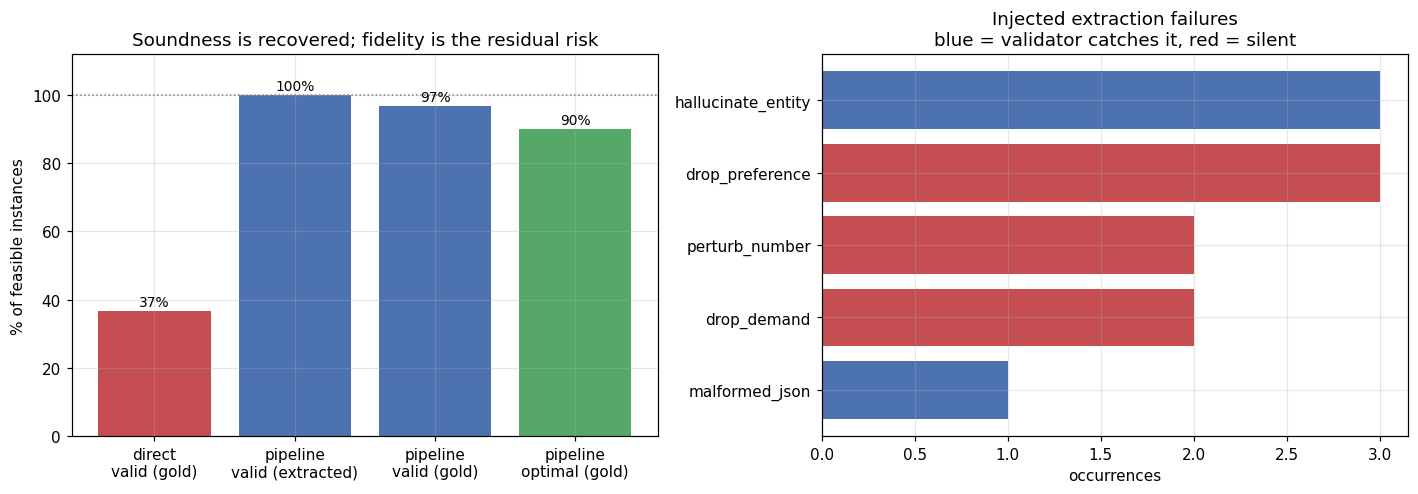

Left panel, read carefully:
 * bar 2 is 100% by construction -- a roster that fails verification is never returned;
   that is a structural property of the architecture, not a measurement of a model.
 * the gap between bar 2 and bar 3 is translation error surviving every gate. It is the
   honest cost of putting a language model in front of a sound solver, and the reason the
   extracted specification should be shown to a human before the roster is published.
 * bar 4 (optimality) is a strictly stronger claim than validity and comes for free from
   MaxSAT -- the direct baseline has no notion of an optimum at all.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

labels = ["direct\nvalid (gold)", "pipeline\nvalid (extracted)",
          "pipeline\nvalid (gold)", "pipeline\noptimal (gold)"]
vals = [100 * _feas.direct_valid_gold.mean(), 100 * _feas.pipe_valid_extracted.mean(),
        100 * _feas.pipe_valid_gold.mean(), 100 * _feas.pipe_optimal_gold.mean()]
bars = axes[0].bar(labels, vals, color=["#c44e52", "#4c72b0", "#4c72b0", "#55a868"])
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 1.5, "%.0f%%" % v, ha="center", fontsize=9)
axes[0].set_ylim(0, 112)
axes[0].set_ylabel("% of feasible instances")
axes[0].set_title("Soundness is recovered; fidelity is the residual risk")
axes[0].axhline(100, ls=":", lw=1, color="grey")

modes = Counter(m for s in EXP.failure_modes for m in s.split(";") if m)
if modes:
    names = [m for m, _ in modes.most_common()]
    counts = [modes[m] for m in names]
    colors = ["#4c72b0" if m.split("(")[0] in STRUCTURAL_MODES else "#c44e52" for m in names]
    axes[1].barh(names[::-1], counts[::-1], color=colors[::-1])
    axes[1].set_xlabel("occurrences")
    axes[1].set_title("Injected extraction failures\nblue = validator catches it, red = silent")
else:
    axes[1].text(0.5, 0.5, "no extraction failures injected", ha="center")
    axes[1].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUT_DIR"], "fig_trustworthiness.png"), dpi=140,
            bbox_inches="tight")
plt.show()

print("Left panel, read carefully:")
print(" * bar 2 is 100% by construction -- a roster that fails verification is never returned;")
print("   that is a structural property of the architecture, not a measurement of a model.")
print(" * the gap between bar 2 and bar 3 is translation error surviving every gate. It is the")
print("   honest cost of putting a language model in front of a sound solver, and the reason the")
print("   extracted specification should be shown to a human before the roster is published.")
print(" * bar 4 (optimality) is a strictly stronger claim than validity and comes for free from")
print("   MaxSAT -- the direct baseline has no notion of an optimum at all.")

## 10. MaxSAT engines head to head &nbsp;·&nbsp; `experiments/maxsat_comparison.py`

Four engines on the same instances:

| Engine | Family |
|---|---|
| **RC2** | core-guided (OLL) with core exhaustion, core minimisation and adaptive trimming |
| **RC2-plain** | the same OLL loop with all three refinements switched off |
| **WPM1 (this notebook)** | the from-scratch weighted Fu-Malik solver of section 5b |
| **LSU** | linear search sat-unsat -- **unweighted instances only** (PySAT's LSU counts violated clauses) |

Instance families: the scheduling encodings from this notebook (weighted, structured), random
weighted partial MaxSAT (weighted, unstructured), and random *unit-weight* partial MaxSAT, which is
the family where all four engines can be compared at once.

Two questions:

* **Do they agree?** Any disagreement between complete runs is a bug in one of them, and the only
  reason to trust the from-scratch implementation is that it never disagrees. Random weight
  distributions matter here: structured instances alone hide bugs in the weighted core-splitting
  step, which is exactly the part that is easy to get wrong.
* **What do RC2's refinements buy?** `RC2-plain` is the controlled comparison -- same algorithm
  family, same oracle, refinements off -- so the runtime gap to `RC2` isolates their value, and the
  gap from `RC2-plain` to `WPM1` isolates what is left (OLL's cardinality-based relaxation versus
  Fu-Malik's AtMost(1) blockers).

In [15]:
def random_wcnf(rng: random.Random, nv: int = 30, hard_ratio: float = 4.0,
                w_max: int = 9) -> WCNF:
    """Random weighted partial MaxSAT with a satisfiable hard part and a non-trivial optimum.

    The hard part is random 3-SAT near the phase transition with a planted solution (so it is
    satisfiable but has few solutions); the soft part asks for a preferred polarity of every
    variable. Because the hard part is tight, those wishes conflict and the optimum is > 0 --
    a generator whose optimum is always 0 would make the whole comparison vacuous.
    """
    f = WCNF()
    planted = [i if rng.random() < 0.5 else -i for i in range(1, nv + 1)]
    for _ in range(int(nv * hard_ratio)):
        vs = rng.sample(range(1, nv + 1), 3)
        clause = [v if rng.random() < 0.5 else -v for v in vs]
        if not any(l in planted for l in clause):
            pos = rng.randrange(3)
            clause[pos] = planted[abs(clause[pos]) - 1]
        f.append(clause)
    for i in range(1, nv + 1):                       # soft: preferred polarity per variable
        f.append([i if rng.random() < 0.5 else -i], weight=rng.randint(1, w_max))
    for _ in range(nv // 2):                         # plus some soft binary wishes
        vs = rng.sample(range(1, nv + 1), 2)
        f.append([v if rng.random() < 0.5 else -v for v in vs], weight=rng.randint(1, w_max))
    return f


MAXSAT_ENGINES = {
    "RC2": lambda f, tl: solve_rc2(f),
    "RC2-plain": lambda f, tl: solve_rc2(f, adapt=False, exhaust=False, minz=False),
    "WPM1 (this notebook)": lambda f, tl: solve_custom(f, time_limit=tl),
    "LSU (unweighted only)": lambda f, tl: solve_lsu(f, timeout=tl),
}


def maxsat_comparison(instances: List[Tuple[str, WCNF]],
                      time_limit: float = None) -> pd.DataFrame:
    time_limit = time_limit or CONFIG["MAXSAT_TIMEOUT"]
    rows = []
    for name, wcnf in instances:
        block = []
        for label, fn in MAXSAT_ENGINES.items():
            res = fn(wcnf, time_limit)
            block.append({"instance": name, "engine": label, "status": res.status,
                          "cost": res.cost, "time": res.time if res.status != "UNSUPPORTED"
                                                    else np.nan,
                          "vars": wcnf.nv, "hard": len(wcnf.hard), "soft": len(wcnf.soft),
                          "max_weight": int(max(wcnf.wght)) if wcnf.wght else 0,
                          "iterations": res.meta.get("iterations"),
                          "cores": res.meta.get("cores"),
                          "mean_core_size": res.meta.get("mean_core_size")})
        complete = {r["cost"] for r in block if r["status"] == "OPTIMUM"}
        for r in block:
            r["agrees"] = len(complete) <= 1
            r["n_complete"] = len(complete)
        rows.extend(block)
    return pd.DataFrame(rows)


_sched_instances: List[Tuple[str, WCNF]] = []
for _item in BENCH[:8]:
    _e = encode(_item["gold"])
    if solve_rc2(_e.wcnf()).model is not None:            # skip the planted-infeasible ones
        _sched_instances.append(("sched/" + _item["name"], _e.wcnf()))

_rand_rng = random.Random(CONFIG["SEED"])
# Sizes are chosen so the from-scratch solver usually finishes inside its budget. Fu-Malik on
# weighted instances is fragile -- a single instance can be orders of magnitude harder than its
# neighbour -- so a few INCOMPLETE rows here are a genuine result, not a configuration mistake.
_weighted = [("randw/nv%02d" % nv, random_wcnf(_rand_rng, nv=nv, w_max=5))
             for nv in (10, 14, 18, 22, 26)]
_unweighted = [("randu/nv%02d" % nv, random_wcnf(_rand_rng, nv=nv, w_max=1))
               for nv in (14, 18, 22, 26, 30)]

MAXSAT_DF = maxsat_comparison(_sched_instances + _weighted + _unweighted)
MAXSAT_DF.to_csv(os.path.join(CONFIG["OUT_DIR"], "maxsat_comparison.csv"), index=False)

_disagree = MAXSAT_DF[~MAXSAT_DF.agrees]
print("instances compared    :", MAXSAT_DF.instance.nunique())
print("engine runs           :", len(MAXSAT_DF),
      "(of which UNSUPPORTED: %d)" % int((MAXSAT_DF.status == "UNSUPPORTED").sum()))
print("optimum disagreements :", _disagree.instance.nunique(),
      "  <-- must be 0; the from-scratch solver is only credible if it is")
if len(_disagree):
    print(_disagree[["instance", "engine", "status", "cost"]].to_string(index=False))

print("\nnon-trivial optima (a generator with optimum 0 everywhere would prove nothing):")
_opt = MAXSAT_DF[MAXSAT_DF.engine == "RC2"].set_index("instance")["cost"]
print("  min %s   median %s   max %s" % (_opt.min(), _opt.median(), _opt.max()))

print("\nruntime (s) by engine:")
print(MAXSAT_DF.dropna(subset=["time"]).pivot_table(
    index="engine", values="time", aggfunc=["count", "mean", "median", "max"]).round(4).to_string())

print("\nfrom-scratch solver behaviour:")
_own = MAXSAT_DF[MAXSAT_DF.engine.str.startswith("WPM1")]
print(_own[["instance", "status", "cost", "time", "iterations", "cores", "mean_core_size"]]
      .round(4).to_string(index=False))

instances compared    : 17
engine runs           : 68 (of which UNSUPPORTED: 12)
optimum disagreements : 0   <-- must be 0; the from-scratch solver is only credible if it is

non-trivial optima (a generator with optimum 0 everywhere would prove nothing):
  min 5.0   median 22.0   max 89.0

runtime (s) by engine:
                      count    mean  median     max
                       time    time    time    time
engine                                             
LSU (unweighted only)     5  0.0019  0.0018  0.0027
RC2                      17  0.0025  0.0016  0.0134
RC2-plain                17  0.0031  0.0014  0.0260
WPM1 (this notebook)     17  0.0052  0.0043  0.0117

from-scratch solver behaviour:
    instance  status  cost   time  iterations  cores  mean_core_size
sched/inst00 OPTIMUM  71.0 0.0056        18.0   17.0            5.29
sched/inst01 OPTIMUM  89.0 0.0027        11.0   10.0            1.90
sched/inst02 OPTIMUM  38.0 0.0020         8.0    7.0            1.86
sched/inst03 O

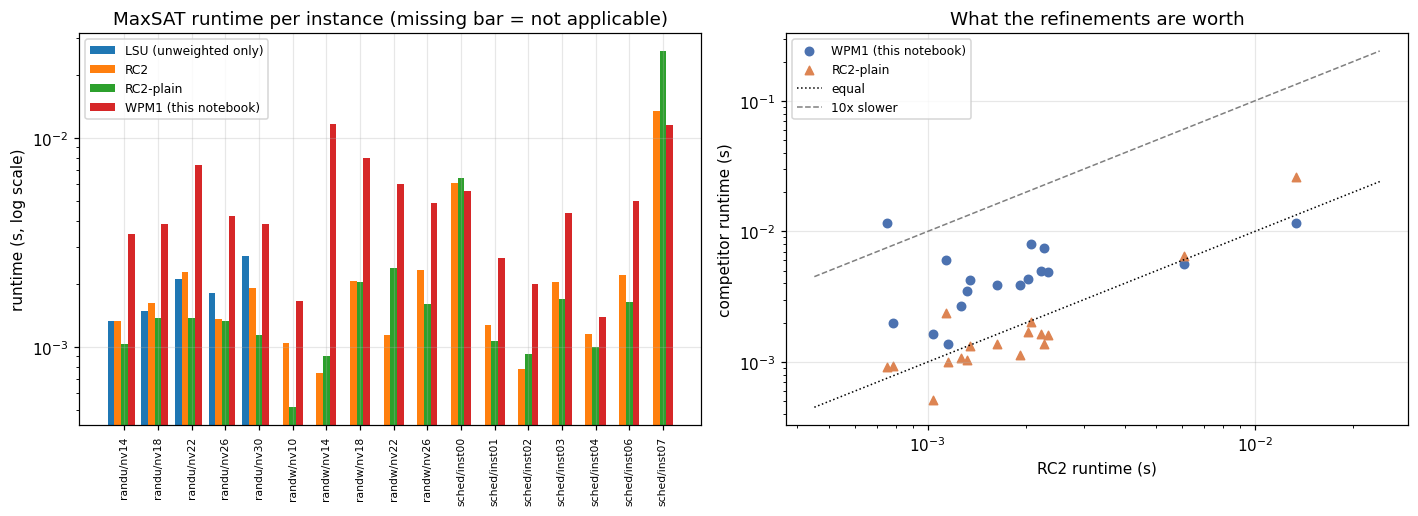

median slowdown vs tuned RC2:  RC2-plain 0.8x   from-scratch WPM1 2.3x
runs that ran out of their 8s budget: 0
Every complete run agrees on the optimum, which is the claim that matters. The remaining
gap is the price of the missing refinements plus a Python-level main loop -- RC2's loop is
Python too, so the comparison is not unfair, but its oracle interaction is far leaner.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

_p = MAXSAT_DF.pivot_table(index="instance", columns="engine", values="time")
_p = _p.loc[sorted(_p.index)]
_x = np.arange(len(_p))
_cols = list(_p.columns)
_w = 0.8 / len(_cols)
for i, col in enumerate(_cols):
    axes[0].bar(_x + i * _w - 0.4, np.nan_to_num(_p[col].values, nan=0.0), _w, label=col)
axes[0].set_yscale("log")
axes[0].set_xticks(_x)
axes[0].set_xticklabels(_p.index, rotation=90, fontsize=7)
axes[0].set_ylabel("runtime (s, log scale)")
axes[0].set_title("MaxSAT runtime per instance (missing bar = not applicable)")
axes[0].legend(fontsize=8)

_ref = MAXSAT_DF[MAXSAT_DF.engine == "RC2"].set_index("instance")["time"]
_mine = MAXSAT_DF[MAXSAT_DF.engine.str.startswith("WPM1")].set_index("instance")["time"]
_plain = MAXSAT_DF[MAXSAT_DF.engine == "RC2-plain"].set_index("instance")["time"]
_common = sorted(set(_ref.index) & set(_mine.index))
axes[1].scatter(_ref.loc[_common], _mine.loc[_common], s=30, color="#4c72b0",
                label="WPM1 (this notebook)")
axes[1].scatter(_ref.loc[_common], _plain.loc[_common], s=30, color="#dd8452", marker="^",
                label="RC2-plain")
_lo = max(1e-4, min(_ref.loc[_common].min(), _mine.loc[_common].min()) * 0.6)
_hi = max(_ref.loc[_common].max(), _mine.loc[_common].max()) * 1.8
axes[1].plot([_lo, _hi], [_lo, _hi], "k:", lw=1, label="equal")
axes[1].plot([_lo, _hi], [10 * _lo, 10 * _hi], color="grey", ls="--", lw=1, label="10x slower")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("RC2 runtime (s)")
axes[1].set_ylabel("competitor runtime (s)")
axes[1].set_title("What the refinements are worth")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUT_DIR"], "fig_maxsat_engines.png"), dpi=140, bbox_inches="tight")
plt.show()

_r_mine = (_mine.loc[_common] / _ref.loc[_common].clip(lower=1e-6)).median()
_r_plain = (_plain.loc[_common] / _ref.loc[_common].clip(lower=1e-6)).median()
_n_incomplete = int((MAXSAT_DF.status == "INCOMPLETE").sum())
print("median slowdown vs tuned RC2:  RC2-plain %.1fx   from-scratch WPM1 %.1fx"
      % (_r_plain, _r_mine))
print("runs that ran out of their %.0fs budget: %d" % (CONFIG["MAXSAT_TIMEOUT"], _n_incomplete))
print("Every complete run agrees on the optimum, which is the claim that matters. The remaining")
print("gap is the price of the missing refinements plus a Python-level main loop -- RC2's loop is")
print("Python too, so the comparison is not unfair, but its oracle interaction is far leaner.")

## 11. Solver benchmarking &nbsp;·&nbsp; `benchmarks/` + `experiments/benchmark_runner.py`

A portfolio of CDCL solvers over four instance families:

| Family | Why it is here |
|---|---|
| **rand3sat** | uniform random 3-SAT around the ratio ~4.26 phase transition -- the classic hardness dial |
| **php** | pigeonhole, `n+1` pigeons into `n` holes -- exponentially hard for resolution, so it separates solvers by preprocessing and restart policy rather than luck |
| **coloring** | random graph 3-colouring near its threshold -- structured, with community structure |
| **sched** | the hard part of the scheduling encodings from this notebook, plus over-constrained (UNSAT) variants -- the application's own instances |

Each `(solver, instance)` pair runs under a wall-clock budget using the `Timer` + `interrupt()` +
`solve_limited` pattern. Timeouts are scored with **PAR2** (penalised average runtime: a timeout
counts as twice the budget), the standard scoring rule of the SAT Competition.

> Sizes are tuned so the whole grid finishes in a couple of minutes on a Colab CPU. Raise
> `CONFIG["BENCH_TIMEOUT"]` and the instance sizes for a serious run, or drop real SAT Competition
> DIMACS files in and read them with `CNF(from_file=...)` -- the harness does not care where the
> clauses came from.

In [17]:
def gen_random_3sat(n: int, ratio: float, rng: random.Random) -> CNF:
    f = CNF()
    for _ in range(int(n * ratio)):
        vs = rng.sample(range(1, n + 1), 3)
        f.append([v if rng.random() < 0.5 else -v for v in vs])
    return f


def gen_pigeonhole(holes: int) -> CNF:
    """holes+1 pigeons into holes holes -- unsatisfiable."""
    f, pool = CNF(), IDPool()
    p = lambda i, j: pool.id(("p", i, j))
    pigeons = holes + 1
    for i in range(pigeons):
        f.append([p(i, j) for j in range(holes)])
    for j in range(holes):
        for i1 in range(pigeons):
            for i2 in range(i1 + 1, pigeons):
                f.append([-p(i1, j), -p(i2, j)])
    return f


def gen_coloring(n: int, edges: int, colors: int, rng: random.Random) -> CNF:
    f, pool = CNF(), IDPool()
    c = lambda v, k: pool.id(("c", v, k))
    for v in range(n):
        f.append([c(v, k) for k in range(colors)])
        for k1 in range(colors):
            for k2 in range(k1 + 1, colors):
                f.append([-c(v, k1), -c(v, k2)])
    seen = set()
    while len(seen) < edges:
        u, w = rng.sample(range(n), 2)
        if (min(u, w), max(u, w)) in seen:
            continue
        seen.add((min(u, w), max(u, w)))
        for k in range(colors):
            f.append([-c(u, k), -c(w, k)])
    return f


def build_sat_benchmark() -> List[Dict[str, Any]]:
    rng = random.Random(CONFIG["SEED"])
    inst: List[Dict[str, Any]] = []

    for n in (90, 120, 150):
        for ratio in (4.1, 4.26, 4.5):
            for rep in range(2):
                inst.append({"name": "rand3sat/n%d_r%.2f_%d" % (n, ratio, rep),
                             "family": "rand3sat",
                             "cnf": gen_random_3sat(n, ratio, rng)})
    for holes in (5, 6, 7):
        inst.append({"name": "php/%d-%d" % (holes + 1, holes), "family": "php",
                     "cnf": gen_pigeonhole(holes)})
    for n, e in ((60, 138), (70, 161), (80, 184)):
        inst.append({"name": "coloring/n%d_e%d" % (n, e), "family": "coloring",
                     "cnf": gen_coloring(n, e, 3, rng)})
    for item in BENCH[:5]:
        inst.append({"name": "sched/" + item["name"], "family": "sched",
                     "cnf": encode(item["gold"]).hard_cnf()})
        tight = copy.deepcopy(item["gold"])            # over-constrain it -> usually UNSAT
        for d in tight["demands"]:
            d["count"] = d["count"] + 1
        for e in tight["employees"]:
            e["max_shifts"] = max(1, e["max_shifts"] - 1)
        inst.append({"name": "sched/" + item["name"] + "_tight", "family": "sched",
                     "cnf": encode(tight).hard_cnf()})
    return inst


def cnf_features(cnf: CNF) -> Dict[str, float]:
    """Instance features for algorithm selection (SATzilla-style, cheap syntactic subset)."""
    clauses = [c for c in cnf.clauses if c]
    nv = max(1, cnf.nv)
    nc = max(1, len(clauses))
    lens = np.array([len(c) for c in clauses], dtype=float)
    pos_counts = Counter()
    neg_counts = Counter()
    n_pos_lits = 0
    n_horn = 0
    for c in clauses:
        p = 0
        for lit in c:
            if lit > 0:
                pos_counts[lit] += 1
                p += 1
            else:
                neg_counts[-lit] += 1
        n_pos_lits += p
        if p <= 1:
            n_horn += 1
    occ = np.array([pos_counts[v] + neg_counts[v] for v in range(1, nv + 1)], dtype=float)
    balance = np.array([abs(pos_counts[v] - neg_counts[v]) / max(1, pos_counts[v] + neg_counts[v])
                        for v in range(1, nv + 1)], dtype=float)
    return {
        "n_vars": float(nv),
        "n_clauses": float(nc),
        "ratio": nc / nv,
        "log_vars": math.log1p(nv),
        "log_clauses": math.log1p(nc),
        "clause_len_mean": float(lens.mean()),
        "clause_len_std": float(lens.std()),
        "clause_len_max": float(lens.max()),
        "frac_unit": float((lens == 1).mean()),
        "frac_binary": float((lens == 2).mean()),
        "frac_ternary": float((lens == 3).mean()),
        "frac_long": float((lens > 3).mean()),
        "pos_lit_frac": n_pos_lits / float(lens.sum()),
        "horn_frac": n_horn / float(nc),
        "occ_mean": float(occ.mean() / nc),
        "occ_std": float(occ.std() / nc),
        "occ_max": float(occ.max() / nc),
        "occ_zero_frac": float((occ == 0).mean()),
        "pn_balance_mean": float(balance.mean()),
        "pn_balance_std": float(balance.std()),
    }


SAT_BENCH = build_sat_benchmark()
FEATURE_NAMES = sorted(cnf_features(SAT_BENCH[0]["cnf"]).keys())
print("benchmark instances: %d  families: %s"
      % (len(SAT_BENCH), dict(Counter(i["family"] for i in SAT_BENCH))))
print("features per instance:", len(FEATURE_NAMES))
print(pd.DataFrame([dict({"instance": i["name"]}, **cnf_features(i["cnf"]))
                    for i in SAT_BENCH[:4]])
      [["instance", "n_vars", "n_clauses", "ratio", "frac_binary", "horn_frac", "occ_max"]]
      .round(3).to_string(index=False))

benchmark instances: 34  families: {'rand3sat': 18, 'php': 3, 'coloring': 3, 'sched': 10}
features per instance: 20
            instance  n_vars  n_clauses  ratio  frac_binary  horn_frac  occ_max
rand3sat/n90_r4.10_0    90.0      368.0  4.089          0.0      0.500    0.054
rand3sat/n90_r4.10_1    90.0      368.0  4.089          0.0      0.486    0.054
rand3sat/n90_r4.26_0    90.0      383.0  4.256          0.0      0.462    0.055
rand3sat/n90_r4.26_1    90.0      383.0  4.256          0.0      0.449    0.063


In [18]:
def run_benchmark(instances: List[Dict[str, Any]], solvers: List[str],
                  timeout: float = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    timeout = timeout or CONFIG["BENCH_TIMEOUT"]
    rows, feats = [], []
    t_start = time.perf_counter()
    for k, inst in enumerate(instances):
        clauses = inst["cnf"].clauses
        feats.append(dict({"instance": inst["name"], "family": inst["family"]},
                          **cnf_features(inst["cnf"])))
        for sv in solvers:
            r = run_sat(clauses, solver=sv, timeout=timeout, want_model=False)
            rows.append({"instance": inst["name"], "family": inst["family"], "solver": sv,
                         "status": {True: "SAT", False: "UNSAT", None: "TIMEOUT"}[r.status],
                         "solved": r.status is not None, "time": r.time,
                         "par2": r.time if r.status is not None else 2 * timeout,
                         "conflicts": r.stats.get("conflicts"),
                         "decisions": r.stats.get("decisions"),
                         "propagations": r.stats.get("propagations")})
        if (k + 1) % 5 == 0 or k + 1 == len(instances):
            print("  %2d/%d instances  (%.1fs elapsed)"
                  % (k + 1, len(instances), time.perf_counter() - t_start))
    return pd.DataFrame(rows), pd.DataFrame(feats)


print("running %d instances x %d solvers, %.1fs budget each ..."
      % (len(SAT_BENCH), len(AVAILABLE_SOLVERS), CONFIG["BENCH_TIMEOUT"]))
RUNS, FEATS = run_benchmark(SAT_BENCH, AVAILABLE_SOLVERS)
RUNS.to_csv(os.path.join(CONFIG["OUT_DIR"], "benchmark_runs.csv"), index=False)
FEATS.to_csv(os.path.join(CONFIG["OUT_DIR"], "benchmark_features.csv"), index=False)

# sanity: solvers must never disagree about satisfiability
_verdicts = (RUNS[RUNS.solved].groupby("instance")["status"].nunique())
_bad = _verdicts[_verdicts > 1]
print("\nsatisfiability disagreements between solvers:", len(_bad), "(must be 0)")
if len(_bad):
    print(RUNS[RUNS.instance.isin(_bad.index)].to_string(index=False))

_summary = RUNS.groupby("solver").agg(solved=("solved", "sum"),
                                      total_time=("time", "sum"),
                                      par2=("par2", "sum"),
                                      mean_time=("time", "mean")).sort_values("par2")
_summary["solved"] = _summary["solved"].astype(int)
print("\nper-solver summary (%d instances):" % RUNS.instance.nunique())
print(_summary.round(3).to_string())
print("\nper-family PAR2:")
print(RUNS.pivot_table(index="solver", columns="family", values="par2", aggfunc="sum")
      .round(2).to_string())

running 34 instances x 6 solvers, 5.0s budget each ...
   5/34 instances  (0.5s elapsed)
  10/34 instances  (3.7s elapsed)
  15/34 instances  (7.3s elapsed)
  20/34 instances  (20.8s elapsed)
  25/34 instances  (22.1s elapsed)
  30/34 instances  (22.1s elapsed)
  34/34 instances  (22.1s elapsed)

satisfiability disagreements between solvers: 0 (must be 0)

per-solver summary (34 instances):
             solved  total_time    par2  mean_time
solver                                            
minisat22        34       0.323   0.323      0.010
cadical195       34       0.509   0.509      0.015
cadical153       34       0.673   0.673      0.020
glucose42        34       0.707   0.707      0.021
mergesat3        34       1.048   1.048      0.031
maplechrono      33      18.788  23.785      0.553

per-family PAR2:
family       coloring   php  rand3sat  sched
solver                                      
cadical153       0.01  0.12      0.54   0.01
cadical195       0.01  0.15      0.35   0.01


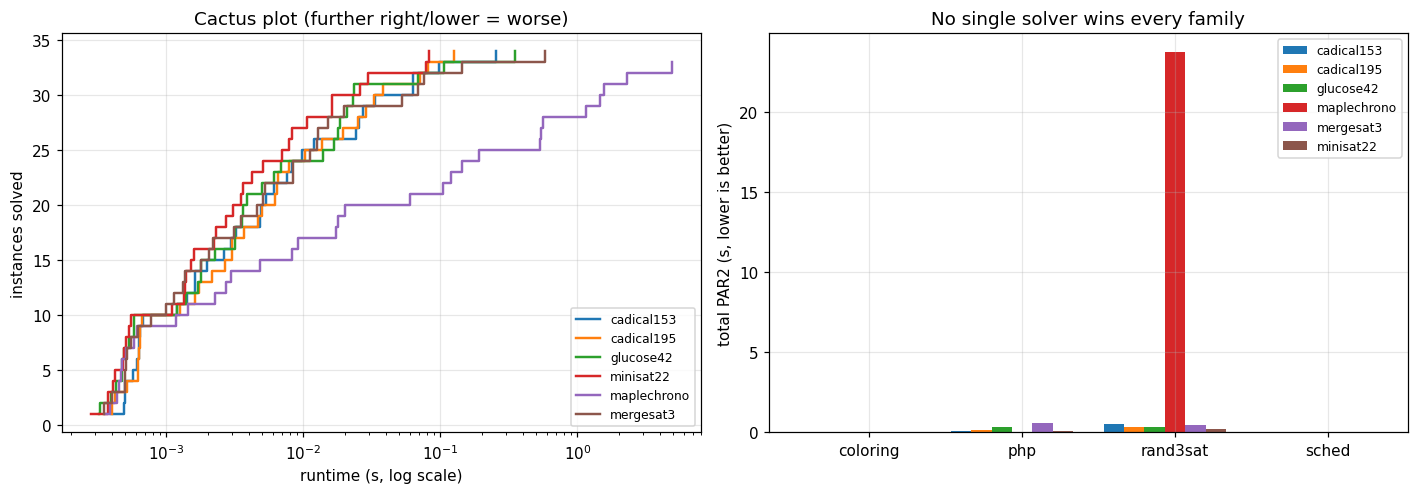

cheapest solver per family:
   coloring   glucose42
   php        maplechrono
   rand3sat   minisat22
   sched      minisat22

That table is the entire motivation for the next section: if the same solver won every
family, algorithm selection would have nothing to learn.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for sv in AVAILABLE_SOLVERS:
    ts = np.sort(RUNS[(RUNS.solver == sv) & RUNS.solved]["time"].values)
    axes[0].step(ts, np.arange(1, len(ts) + 1), where="post", label=sv, lw=1.6)
axes[0].set_xscale("log")
axes[0].set_xlabel("runtime (s, log scale)")
axes[0].set_ylabel("instances solved")
axes[0].set_title("Cactus plot (further right/lower = worse)")
axes[0].legend(fontsize=8, loc="lower right")

_fam = RUNS.pivot_table(index="family", columns="solver", values="par2", aggfunc="sum")
_x = np.arange(len(_fam))
_w = 0.8 / len(_fam.columns)
for i, sv in enumerate(_fam.columns):
    axes[1].bar(_x + i * _w - 0.4, _fam[sv].values, _w, label=sv)
axes[1].set_xticks(_x)
axes[1].set_xticklabels(_fam.index)
axes[1].set_ylabel("total PAR2 (s, lower is better)")
axes[1].set_title("No single solver wins every family")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUT_DIR"], "fig_benchmark.png"), dpi=140, bbox_inches="tight")
plt.show()

_best_per_family = _fam.idxmin(axis=1)
print("cheapest solver per family:")
for fam, sv in _best_per_family.items():
    print("   %-10s %s" % (fam, sv))
print("\nThat table is the entire motivation for the next section: if the same solver won every")
print("family, algorithm selection would have nothing to learn.")

## 12. Machine-learned algorithm selection &nbsp;·&nbsp; `experiments/portfolio_selection.py`

Classic SATzilla-style setup: predict, from cheap syntactic features, **which solver to run**.

* **features** — the 20 syntactic features from section 11 (no probing features, which would need a
  short trial run and would be the obvious next addition)
* **label** — the solver with the lowest runtime on that instance
* **model** — a random forest, evaluated with 5-fold **cross-validated** predictions so no instance
  is ever scored by a model that saw it
* **baselines** — every single solver, the **single best solver** (SBS, the best fixed choice in
  hindsight), and the **virtual best solver** (VBS, the unreachable per-instance oracle)

The number that matters is where the selector lands between SBS and VBS: that is the fraction of the
available oracle gap it actually captures.

> **Honest caveat.** With a few dozen generated instances and six solvers this is a *demonstration of
> the methodology*, not a result. The gap between SBS and VBS is small here, cross-validated variance
> is large, and a selector can easily come out behind SBS -- if it does, that is reported as-is
> below rather than hidden. A real study needs thousands of SAT Competition instances, probing
> features, per-family stratification and a cost-sensitive loss (predicting runtime and picking the
> argmin, rather than classifying the winner). The harness scales to that unchanged.

instances usable for selection: 34   distinct winners: {'minisat22': 21, 'glucose42': 5, 'mergesat3': 3, 'maplechrono': 3, 'cadical195': 1, 'cadical153': 1}

total PAR2 over 34 instances (lower is better)
   virtual best (oracle)                  0.23 s
   learned selector (5-fold CV)           0.24 s
   single best solver (minisat22)         0.32 s
   random solver choice                   4.51 s

accuracy of winner prediction : 55.9 %
oracle gap captured by selector: 84.7 %
(negative means the selector is worse than just always running minisat22)


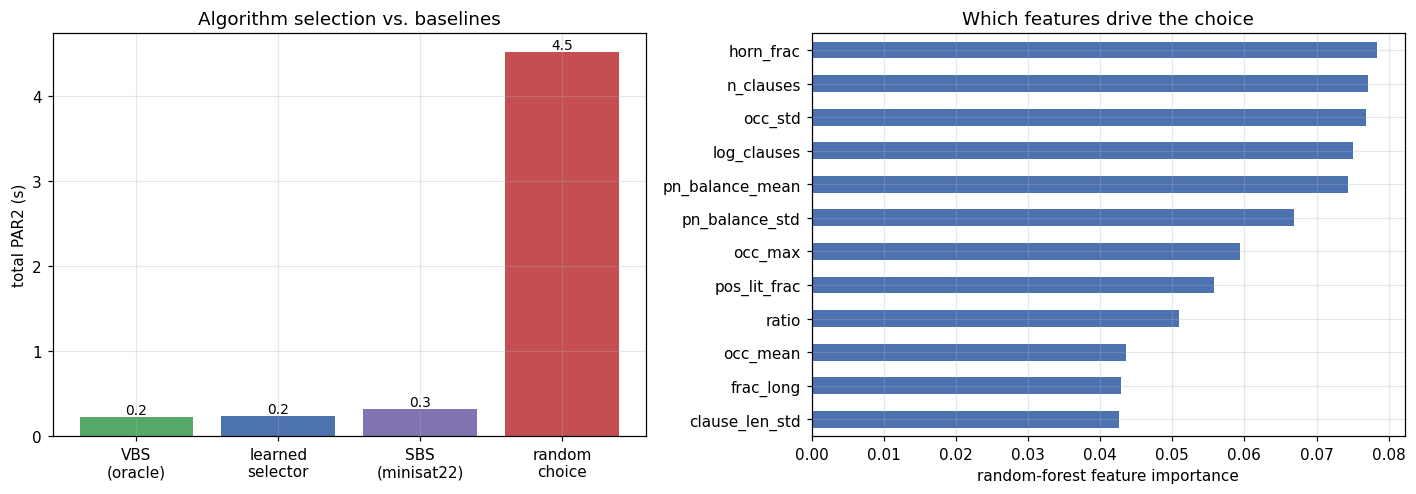

In [20]:
if not HAVE_SKLEARN:
    print("scikit-learn unavailable -- skipping algorithm selection")
else:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import KFold, cross_val_predict

    TIMEOUT = CONFIG["BENCH_TIMEOUT"]
    par2 = RUNS.pivot_table(index="instance", columns="solver", values="par2")
    solved_any = RUNS.groupby("instance")["solved"].any()
    usable = par2.loc[solved_any[solved_any].index].sort_index()
    feats = FEATS.set_index("instance").loc[usable.index]

    X = feats[FEATURE_NAMES].values
    y = par2.loc[usable.index].idxmin(axis=1).values          # fastest solver per instance
    fams = feats["family"].values

    print("instances usable for selection: %d   distinct winners: %s"
          % (len(usable), dict(Counter(y))))

    clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=1,
                                 random_state=CONFIG["SEED"], n_jobs=-1)
    kf = KFold(n_splits=min(5, len(usable)), shuffle=True, random_state=CONFIG["SEED"])
    y_pred = cross_val_predict(clf, X, y, cv=kf)

    sel_par2 = float(sum(usable.loc[inst, sv] for inst, sv in zip(usable.index, y_pred)))
    vbs_par2 = float(usable.min(axis=1).sum())
    single = usable.sum(axis=0).sort_values()
    sbs_name, sbs_par2 = single.index[0], float(single.iloc[0])
    rnd_par2 = float(usable.mean(axis=1).sum())        # expected cost of a random pick

    gap = sbs_par2 - vbs_par2
    captured = (sbs_par2 - sel_par2) / gap if gap > 1e-9 else float("nan")

    print("\ntotal PAR2 over %d instances (lower is better)" % len(usable))
    for label, val in [("virtual best (oracle)", vbs_par2),
                       ("learned selector (5-fold CV)", sel_par2),
                       ("single best solver (%s)" % sbs_name, sbs_par2),
                       ("random solver choice", rnd_par2)]:
        print("   %-34s %8.2f s" % (label, val))
    print("\naccuracy of winner prediction : %.1f %%" % (100 * (y_pred == y).mean()))
    print("oracle gap captured by selector: %.1f %%" % (100 * captured))
    print("(negative means the selector is worse than just always running %s)" % sbs_name)

    clf.fit(X, y)
    imp = pd.Series(clf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    labels = ["VBS\n(oracle)", "learned\nselector", "SBS\n(%s)" % sbs_name, "random\nchoice"]
    vals = [vbs_par2, sel_par2, sbs_par2, rnd_par2]
    cols = ["#55a868", "#4c72b0", "#8172b2", "#c44e52"]
    bars = axes[0].bar(labels, vals, color=cols)
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x() + b.get_width() / 2, v, "%.1f" % v, ha="center",
                     va="bottom", fontsize=9)
    axes[0].set_ylabel("total PAR2 (s)")
    axes[0].set_title("Algorithm selection vs. baselines")

    imp.head(12)[::-1].plot(kind="barh", ax=axes[1], color="#4c72b0")
    axes[1].set_xlabel("random-forest feature importance")
    axes[1].set_title("Which features drive the choice")
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["OUT_DIR"], "fig_selection.png"), dpi=140, bbox_inches="tight")
    plt.show()

    pd.DataFrame({"instance": usable.index, "family": fams, "true_best": y,
                  "predicted": y_pred}).to_csv(
        os.path.join(CONFIG["OUT_DIR"], "selection_predictions.csv"), index=False)

## 13. DIMACS / WDIMACS interoperability

The pipeline speaks the standard formats, so its instances can be thrown at any external solver
(CaDiCaL, Kissat, Open-WBO, EvalMaxSAT, ...) and any competition instance can be read back in. That
matters for two reasons: it makes the benchmark reproducible outside this notebook, and it is what
would let the encodings be submitted to a MaxSAT Evaluation track.

In [21]:
_dimacs_dir = os.path.join(CONFIG["OUT_DIR"], "dimacs")
os.makedirs(_dimacs_dir, exist_ok=True)

_enc_demo = encode(DEMO["gold"])
_cnf_path = os.path.join(_dimacs_dir, "%s_hard.cnf" % DEMO["name"])
_wcnf_path = os.path.join(_dimacs_dir, "%s.wcnf" % DEMO["name"])
_enc_demo.hard_cnf().to_file(_cnf_path)
_enc_demo.wcnf().to_file(_wcnf_path)

_reread = WCNF(from_file=_wcnf_path)
_a, _b = solve_rc2(_enc_demo.wcnf()), solve_rc2(_reread)
print("wrote %s  (%d bytes)" % (_cnf_path, os.path.getsize(_cnf_path)))
print("wrote %s (%d bytes)" % (_wcnf_path, os.path.getsize(_wcnf_path)))
print("optimum in memory %s  ==  optimum after round-trip %s -> %s"
      % (_a.cost, _b.cost, _a.cost == _b.cost))
print("\nhead of the WDIMACS file:")
with open(_wcnf_path) as _fh:
    for _i, _line in enumerate(_fh):
        if _i >= 6:
            break
        print("  " + _line.rstrip())
print("""
To run an external solver on these files:
    kissat  %s
    open-wbo %s""" % (_cnf_path, _wcnf_path))

wrote llm2sat_artifacts/dimacs/inst00_hard.cnf  (2263 bytes)
wrote llm2sat_artifacts/dimacs/inst00.wcnf (3009 bytes)
optimum in memory 71  ==  optimum after round-trip 71 -> True

head of the WDIMACS file:
  4 18 0
  4 -29 0
  5 11 0
  4 -91 0
  4 -100 0
  4 -109 0

To run an external solver on these files:
    kissat  llm2sat_artifacts/dimacs/inst00_hard.cnf
    open-wbo llm2sat_artifacts/dimacs/inst00.wcnf


## 14. Test suite &nbsp;·&nbsp; `tests/`

The tests are the argument that any of the above is true. In particular:

* **`test_encoding_is_sound`** enumerates many models of the hard CNF and runs each through the
  independent verifier. If the encoding were too permissive, some model would fail.
* **`test_encoding_is_complete`** checks the other direction on a small instance: a roster the
  verifier accepts must be extendable to a model of the CNF, so the encoding does not silently
  forbid legal rosters.
* **`test_custom_matches_rc2_*`** compares the from-scratch WPM1 optimum against RC2 on random
  weighted and structured instances.
* **`test_objective_agrees`** is the differential test that catches encoding/objective drift.
* **`test_mus_is_minimal`** confirms the explanation is genuinely irreducible.

In [22]:
import unittest


def _models(clauses, limit=25, projection=None):
    """Enumerate up to `limit` models, blocking on the projection variables."""
    out = []
    with Solver(name="cadical153", bootstrap_with=[list(c) for c in clauses]) as s:
        while len(out) < limit and s.solve():
            m = s.get_model()
            out.append(m)
            block = [-lit for lit in m if projection is None or abs(lit) in projection]
            if not block:
                break
            s.add_clause(block)
    return out


def _groups_sat(enc: Encoding, names) -> bool:
    clauses = list(enc.groups.get("axiom[false]", []))
    for n in names:
        clauses += enc.groups[n]
    with Solver(name="cadical153", bootstrap_with=[list(c) for c in clauses]) as s:
        return bool(s.solve())


class TestSchema(unittest.TestCase):
    def test_generator_emits_valid_specs(self):
        rng = random.Random(3)
        for _ in range(25):
            self.assertEqual(validate_spec(generate_gold_spec(rng)), [])

    def test_rejects_corruptions(self):
        spec = copy.deepcopy(DEMO["gold"])
        bad = copy.deepcopy(spec); del bad["rules"]
        self.assertTrue(validate_spec(bad))
        bad = copy.deepcopy(spec); bad["soft"][0]["type"] = "make_everyone_happy"
        self.assertTrue(validate_spec(bad))
        bad = copy.deepcopy(spec); bad["demands"][0]["day"] = "Sunday"
        self.assertTrue(validate_spec(bad))
        bad = copy.deepcopy(spec); bad["employees"][0]["cost_band"] = 99
        self.assertTrue(validate_spec(bad))
        bad = copy.deepcopy(spec)
        bad["soft"].append({"id": "x", "type": "prefer_shift", "weight": 2,
                            "employee": "Zoltan", "day": bad["days"][0],
                            "shift": bad["shifts"][0]})
        self.assertTrue(any("Zoltan" in e for e in validate_spec(bad)))

    def test_normalize_maps_empty_string_to_none(self):
        wire = {"days": ["Mon"], "shifts": ["am"], "employees": [], "demands": [], "rules": {},
                "soft": [{"id": "c", "type": "minimize_cost", "weight": "2",
                          "employee": "", "day": "", "shift": ""}]}
        norm = normalize_spec(wire)
        self.assertIsNone(norm["soft"][0]["employee"])
        self.assertEqual(norm["soft"][0]["weight"], 2)

    def test_fidelity_is_one_for_identity(self):
        self.assertEqual(fidelity(DEMO["gold"], copy.deepcopy(DEMO["gold"]))["f1"], 1.0)
        self.assertEqual(fidelity(DEMO["gold"], None)["f1"], 0.0)


class TestEncoding(unittest.TestCase):
    def test_encoding_is_sound(self):
        """Every model of the hard CNF decodes to a roster the independent verifier accepts."""
        rng = random.Random(5)
        checked = 0
        for _ in range(4):
            spec = generate_gold_spec(rng, n_emp=4, n_days=3, n_skills=2)
            enc = encode(spec)
            proj = set(enc.var.values())
            for m in _models(enc.hard_cnf().clauses, limit=15, projection=proj):
                rep = verify(spec, enc.decode(m))
                self.assertTrue(rep.ok, "encoding admitted an invalid roster: %s"
                                % [v.detail for v in rep.violations][:3])
                checked += 1
        self.assertGreater(checked, 0)

    def test_encoding_is_complete(self):
        """A roster the verifier accepts is consistent with the hard CNF (no legal roster is lost)."""
        rng = random.Random(6)
        spec = generate_gold_spec(rng, n_emp=3, n_days=2, n_skills=2)
        enc = encode(spec)
        keys = sorted(enc.var)
        tried = 0
        for bits in range(2 ** len(keys)):
            if tried >= 400:
                break
            assignment = {keys[i] for i in range(len(keys)) if bits >> i & 1}
            if not verify(spec, assignment).ok:
                continue
            tried += 1
            units = [enc.var[k] if k in assignment else -enc.var[k] for k in keys]
            r = run_sat(enc.hard_cnf().clauses + [[u] for u in units], want_model=False)
            self.assertTrue(r.status, "verifier accepted a roster the CNF forbids")

    def test_objective_agrees(self):
        """MaxSAT optimum == penalty recomputed by the independent verifier."""
        rng = random.Random(7)
        n = 0
        for _ in range(8):
            spec = generate_gold_spec(rng, n_emp=5, n_days=3)
            enc = encode(spec)
            res = solve_rc2(enc.wcnf())
            if res.model is None:
                continue
            cc = cross_check(enc, res)
            self.assertTrue(cc.verified, "optimal model failed verification")
            self.assertTrue(cc.cost_agrees,
                            "objective drift: solver %s vs verifier %s"
                            % (cc.solver_cost, cc.verifier_cost))
            n += 1
        self.assertGreater(n, 0)

    def test_balance_ladder_is_linear(self):
        """The soft-cardinality ladder must charge w per shift above target, not a flat w."""
        spec = {"days": ["Mon", "Tue", "Wed"], "shifts": ["am", "pm"],
                "employees": [{"name": "A", "skills": ["k"], "max_shifts": 6, "cost_band": 1,
                               "unavailable": []},
                              {"name": "B", "skills": ["k"], "max_shifts": 6, "cost_band": 1,
                               "unavailable": []}],
                "demands": [{"day": "Mon", "shift": "am", "skill": "k", "count": 1}],
                "rules": {"at_most_one_shift_per_day": True, "rest_after_evening": False,
                          "skill_gated_shifts": False},
                "soft": [{"id": "b", "type": "balance_workload", "weight": 3,
                          "employee": None, "day": None, "shift": None}]}
        target = balance_target(spec)
        enc = encode(spec)
        for extra in (0, 1, 2):
            load = target + extra
            assignment = {("A", d, s) for d in spec["days"] for s in spec["shifts"]}
            assignment = set(sorted(assignment)[:load]) | {("B", "Mon", "am")}
            b_load = 1
            expected = 3 * (max(0, load - target) + max(0, b_load - target))
            self.assertEqual(verify(spec, assignment).total_cost, expected)

    def test_card_helper_edge_cases(self):
        e = SchedulingEncoder(DEMO["gold"])
        self.assertEqual(e._card([1, 2, 3], 3, "atmost"), [])       # vacuous
        self.assertEqual(e._card([1, 2, 3], 0, "atleast"), [])      # vacuous
        self.assertEqual(e._card([1, 2], 5, "atleast"), [[e._false]])   # impossible


class TestVerifier(unittest.TestCase):
    def test_catches_each_violation_kind(self):
        spec = {"days": ["Mon", "Tue"], "shifts": ["am", "pm"],
                "employees": [{"name": "A", "skills": ["k"], "max_shifts": 1, "cost_band": 1,
                               "unavailable": [{"day": "Tue", "shift": "pm"}]},
                              {"name": "B", "skills": ["j"], "max_shifts": 4, "cost_band": 1,
                               "unavailable": []}],
                "demands": [{"day": "Mon", "shift": "am", "skill": "k", "count": 1},
                            {"day": "Mon", "shift": "pm", "skill": "j", "count": 1}],
                "rules": {"at_most_one_shift_per_day": True, "rest_after_evening": True,
                          "skill_gated_shifts": True},
                "soft": []}
        kinds = lambda a: {v.kind for v in verify(spec, a).violations}
        self.assertIn("coverage", kinds(set()))
        self.assertIn("availability", kinds({("A", "Tue", "pm")}))
        self.assertIn("max_shifts", kinds({("A", "Mon", "am"), ("A", "Tue", "am")}))
        self.assertIn("one_per_day", kinds({("B", "Mon", "am"), ("B", "Mon", "pm")}))
        self.assertIn("rest", kinds({("B", "Mon", "pm"), ("B", "Tue", "am")}))
        self.assertIn("skill_gate", kinds({("B", "Mon", "am")}))
        self.assertIn("unknown_employee", kinds({("Zoltan", "Mon", "am")}))

    def test_accepts_a_correct_roster(self):
        spec = {"days": ["Mon"], "shifts": ["am"],
                "employees": [{"name": "A", "skills": ["k"], "max_shifts": 1, "cost_band": 2,
                               "unavailable": []}],
                "demands": [{"day": "Mon", "shift": "am", "skill": "k", "count": 1}],
                "rules": {"at_most_one_shift_per_day": True, "rest_after_evening": True,
                          "skill_gated_shifts": True},
                "soft": [{"id": "c", "type": "minimize_cost", "weight": 1,
                          "employee": None, "day": None, "shift": None}]}
        rep = verify(spec, {("A", "Mon", "am")})
        self.assertTrue(rep.ok)
        self.assertEqual(rep.total_cost, 2)          # one shift, cost band 2, weight 1


class TestMaxSAT(unittest.TestCase):
    def test_custom_matches_rc2_random(self):
        """Whenever WPM1 completes, its optimum must equal RC2's. Timeouts are allowed, wrong
        answers are not -- Fu-Malik is genuinely fragile on weighted instances."""
        rng = random.Random(21)
        complete = 0
        for i in range(14):
            wcnf = random_wcnf(rng, nv=rng.choice([10, 12, 14]), w_max=rng.choice([1, 3, 5]))
            a, b = solve_rc2(wcnf), solve_custom(wcnf, time_limit=10)
            if b.status != "OPTIMUM":
                continue
            complete += 1
            self.assertEqual(a.cost, b.cost,
                             "instance %d: RC2 %s vs WPM1 %s" % (i, a.cost, b.cost))
        self.assertGreaterEqual(complete, 10, "WPM1 timed out far more often than expected")

    def test_custom_matches_rc2_scheduling(self):
        rng = random.Random(22)
        n = 0
        for _ in range(6):
            spec = generate_gold_spec(rng, n_emp=4, n_days=3)
            wcnf = encode(spec).wcnf()
            a = solve_rc2(wcnf)
            b = solve_custom(wcnf, time_limit=20)
            if a.status == "UNSAT":
                self.assertEqual(b.status, "UNSAT")
                continue
            self.assertEqual(b.status, "OPTIMUM")
            self.assertEqual(a.cost, b.cost)
            n += 1
        self.assertGreater(n, 0)

    def test_lsu_matches_rc2_unweighted(self):
        rng = random.Random(23)
        for _ in range(4):
            wcnf = random_wcnf(rng, nv=20, w_max=1)
            self.assertEqual(solve_rc2(wcnf).cost, solve_lsu(wcnf).cost)

    def test_lsu_refuses_weighted_input(self):
        rng = random.Random(24)
        self.assertEqual(solve_lsu(random_wcnf(rng, nv=15, w_max=5)).status, "UNSUPPORTED")

    def test_unsat_hard_part(self):
        f = WCNF()
        f.append([1]); f.append([-1])
        f.append([2], weight=3)
        self.assertEqual(solve_custom(f).status, "UNSAT")
        self.assertEqual(solve_rc2(f).status, "UNSAT")

    def test_dimacs_roundtrip(self):
        path = os.path.join(CONFIG["OUT_DIR"], "dimacs", "_rt.wcnf")
        wcnf = encode(DEMO["gold"]).wcnf()
        wcnf.to_file(path)
        self.assertEqual(solve_rc2(wcnf).cost, solve_rc2(WCNF(from_file=path)).cost)


class TestExplanation(unittest.TestCase):
    def test_mus_is_minimal(self):
        rng = random.Random(31)
        found = 0
        for _ in range(25):
            spec = generate_gold_spec(rng, n_emp=4, n_days=3, force_infeasible=True)
            enc = encode(spec)
            mus = group_mus(enc)
            if mus is None:
                continue                                  # over-constraint did not bite
            found += 1
            self.assertFalse(_groups_sat(enc, mus), "MUS is satisfiable")
            for g in mus:
                self.assertTrue(_groups_sat(enc, [x for x in mus if x != g]),
                                "MUS is not minimal: %s was redundant" % g)
            if found >= 3:
                break
        self.assertGreater(found, 0, "no infeasible instance produced")

    def test_feasible_instance_has_no_mus(self):
        rng = random.Random(32)
        spec = generate_gold_spec(rng, n_emp=6, n_days=3, n_skills=2)
        enc = encode(spec)
        if solve_rc2(enc.wcnf()).model is not None:
            self.assertIsNone(group_mus(enc))


class TestPipeline(unittest.TestCase):
    def test_pipeline_never_returns_an_invalid_roster(self):
        """The central architectural claim, tested against a deliberately unreliable extractor."""
        for k, item in enumerate(BENCH[:10]):
            backend = SurrogateLLM(item["gold"], random.Random(100 + k), error_rate=0.9)
            pr = run_pipeline(item, backend=backend)
            self.assertIn(pr.status, ("EXTRACTION_FAILED", "INFEASIBLE", "SOLVED"))
            if pr.status == "SOLVED":
                self.assertTrue(pr.cc.verified)
                self.assertTrue(pr.cc.cost_agrees)
                self.assertTrue(verify(pr.extraction.spec, pr.assignment).ok)

    def test_repair_loop_fixes_structural_errors(self):
        item = BENCH[1]
        backend = SurrogateLLM(item["gold"], random.Random(4), error_rate=1.0,
                               repair_success=1.0)
        res = parse_requirements(item, backend=backend, max_repairs=3)
        self.assertTrue(res.ok)


_suite = unittest.TestLoader().loadTestsFromNames([
    "__main__.TestSchema", "__main__.TestEncoding", "__main__.TestVerifier",
    "__main__.TestMaxSAT", "__main__.TestExplanation", "__main__.TestPipeline",
])
_result = unittest.TextTestRunner(verbosity=2).run(_suite)
print("\ntests run: %d   failures: %d   errors: %d"
      % (_result.testsRun, len(_result.failures), len(_result.errors)))

test_fidelity_is_one_for_identity (__main__.TestSchema.test_fidelity_is_one_for_identity) ... ok
test_generator_emits_valid_specs (__main__.TestSchema.test_generator_emits_valid_specs) ... ok
test_normalize_maps_empty_string_to_none (__main__.TestSchema.test_normalize_maps_empty_string_to_none) ... ok
test_rejects_corruptions (__main__.TestSchema.test_rejects_corruptions) ... ok
test_balance_ladder_is_linear (__main__.TestEncoding.test_balance_ladder_is_linear)
The soft-cardinality ladder must charge w per shift above target, not a flat w. ... ok
test_card_helper_edge_cases (__main__.TestEncoding.test_card_helper_edge_cases) ... ok
test_encoding_is_complete (__main__.TestEncoding.test_encoding_is_complete)
A roster the verifier accepts is consistent with the hard CNF (no legal roster is lost). ... ok
test_encoding_is_sound (__main__.TestEncoding.test_encoding_is_sound)
Every model of the hard CNF decodes to a roster the independent verifier accepts. ... ok
test_objective_agrees (__main


tests run: 21   failures: 0   errors: 0


## 15. Artifacts

Everything the notebook measured is written to `llm2sat_artifacts/` and zipped: the experiment CSVs,
the benchmark runs and features, the figures, the DIMACS/WDIMACS instances, and the demo
specification and roster as JSON. On Colab, download the zip from the file browser on the left or
with `google.colab.files.download`.

In [23]:
_demo_bundle = {
    "requirements_text": DEMO["text"],
    "gold_spec": DEMO["gold"],
    "extracted_spec": _pr.extraction.spec,
    "extraction": {"attempts": _pr.extraction.attempts,
                   "errors_per_attempt": _pr.extraction.error_log,
                   "surrogate_failure_modes": _pr.extraction.failure_modes},
    "encoding_stats": _pr.enc.stats if _pr.enc else None,
    "maxsat": {"algo": _pr.solution.algo, "status": _pr.solution.status,
               "cost": _pr.solution.cost, "time_s": round(_pr.solution.time, 4)}
              if _pr.solution else None,
    "verification": {"valid": bool(_pr.cc.verified), "cost_agrees": bool(_pr.cc.cost_agrees),
                     "solver_cost": _pr.cc.solver_cost, "verifier_cost": _pr.cc.verifier_cost}
                    if _pr.cc else None,
    "roster": sorted(list(_pr.assignment)) if _pr.assignment else None,
    "explanation": _pr.explanation(),
}
with open(os.path.join(CONFIG["OUT_DIR"], "demo_run.json"), "w") as _fh:
    json.dump(_demo_bundle, _fh, indent=2)

with open(os.path.join(CONFIG["OUT_DIR"], "requirements.txt"), "w") as _fh:
    _fh.write("python-sat>=1.8.dev\nnumpy\npandas\nmatplotlib\nscikit-learn\nanthropic\n")

_zip_path = CONFIG["OUT_DIR"] + ".zip"
with zipfile.ZipFile(_zip_path, "w", zipfile.ZIP_DEFLATED) as _z:
    for _root, _dirs, _files in os.walk(CONFIG["OUT_DIR"]):
        for _f in _files:
            _full = os.path.join(_root, _f)
            _z.write(_full, os.path.relpath(_full, CONFIG["OUT_DIR"]))

print("artifacts in", os.path.abspath(CONFIG["OUT_DIR"]))
for _root, _dirs, _files in sorted(os.walk(CONFIG["OUT_DIR"])):
    for _f in sorted(_files):
        _p = os.path.join(_root, _f)
        print("   %-46s %8.1f KB" % (os.path.relpath(_p, CONFIG["OUT_DIR"]),
                                     os.path.getsize(_p) / 1024))
print("\nzipped ->", os.path.abspath(_zip_path))
print("on Colab:  from google.colab import files; files.download('%s')" % _zip_path)

artifacts in /content/llm2sat_artifacts
   benchmark_features.csv                              9.6 KB
   benchmark_runs.csv                                 20.3 KB
   demo_run.json                                      10.4 KB
   experiment_trustworthiness.csv                      5.1 KB
   fig_benchmark.png                                  84.6 KB
   fig_maxsat_engines.png                             93.0 KB
   fig_selection.png                                  72.0 KB
   fig_trustworthiness.png                            70.5 KB
   maxsat_comparison.csv                               5.5 KB
   requirements.txt                                    0.1 KB
   selection_predictions.csv                           1.6 KB
   dimacs/_rt.wcnf                                     2.9 KB
   dimacs/inst00.wcnf                                  2.9 KB
   dimacs/inst00_hard.cnf                              2.2 KB

zipped -> /content/llm2sat_artifacts.zip
on Colab:  from google.colab import files; files.d